# pyGAM dengue incidence + mortality — predict → aggregate → validate

Python/pyGAM analog of `03_modeling/fit_dengue_models_explore.r`, now carried through the
**full** flow that R script sketches, for **both outcomes**: fit the base age/sex group
incidence model *and* a base-group CFR model, broadcast to age/sex via the observed
relative-risk pattern, derive mortality as `incidence × CFR`, aggregate all-age up the GBD
hierarchy in **count space**, and validate aggregated predicted vs observed incidence,
mortality, and CFR at every level (especially super-region and global).

The machinery is packaged as reusable functions and driven by a **formulation registry**, so
several model formulations (and fit grains) run through the identical pipeline and drop out a
single `(formulation × level × measure)` summary of correlation / slope / intercept / R² for
side-by-side comparison.

**Design decisions (reconciled against the three sibling implementations):**
- **Base age/sex group = age 3 / sex 1**, sourced from `mbpc.cause_map['dengue']`. The R explorer
  hardcodes `7 / 2` with a `<<CONFIRM>>`; `cause_map`, the production draw builder, and
  `notebooks/modeling/dengue/dengue_base_incidence_optimize.ipynb` all use `3 / 1`.
- **Relative risk = age/sex rate ÷ base-group rate** (2023 observed AS snapshot), so the base
  group has `rr == 1` and age/sex rate is reconstructed multiplicatively as
  `exp(base_log_pred) × rr` — the R convention. (`dengue_base_incidence_optimize.ipynb` instead
  defines rr against the *all-age* rate and feeds it as a GAM covariate; not interchangeable — we
  mirror the R base-group convention as the task specifies.)
- **Shift** adds a per-location constant so predictions line up with the observed base-group
  value over an anchor window (R 128–138). Configurable via `ANCHOR_MODE` — `point`
  (single-year 2023, the R behaviour), `median_resid` (median of per-year residuals), or the
  default `median_diff` (difference of medians) over `ANCHOR_YEARS = 2019–2023`, which is more
  robust to spiky single-year observations. **Incidence and CFR share the same anchor settings**
  (mode + years), each applied in its model's natural space: **log** for incidence, **logit** for
  CFR.
- **Mortality via CFR.** A base-group CFR model (`logit(cfr) ~ log_gdppc_mean + A0`, borrowed
  from `final_models_dengue.r::mod_cfr_base`) is fit, shifted, and back-transformed (`expit`) to a
  per-(location, year) CFR, broadcast across age/sex, so `mort_count = inc_count × cfr` via the
  canonical `disaggregate_age_sex_dengue` helper. CFR is a *base-group* prediction here, so
  mortality inherits incidence's age/sex shape; an `as_id` age/sex-specific CFR (as in the
  production/OLD pipeline) is an extension point.
- **Fit grain** is selected per formulation via the `most_detailed_*` flag: `lsae` = admin-2
  (level 5), `fhs` = FHS most-detailed (levels 3–4). Aggregation must filter to one grain first
  (the past-inputs now span levels 3–5) or it double-counts.

Reuses `specs` / `fit` / `viz` / `metrics` from `idd_forecast_mbp.lib.modeling`, the count-space
aggregator in `lib.processing.aggregation`, and `lib.data.hierarchy`. Paths resolve via
`constants` — no hardcoded absolutes.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp import constants as mbpc
from idd_forecast_mbp.lib.modeling import specs, fit, viz, metrics
from idd_forecast_mbp.lib.data.hierarchy import load_hierarchy
from idd_forecast_mbp.lib.processing.aggregation import (
    aggregate_aa_rate_lsae_to_gbd,
    make_rate_from_count,
)
from idd_forecast_mbp.lib.processing.disaggregation import disaggregate_age_sex_dengue
from idd_forecast_mbp.lib.utils.transforms import logit, expit

## Load data

Everything the pipeline needs, loaded once:

- **past-inputs** (`dengue_past_inputs.parquet`) — AS covariates + incidence at every grain
  (levels 3–5), carrying the `most_detailed_{lsae,fhs,gbd}` flags and `population` (age/sex).
- **hierarchy** — level, `parent_id`, `path_to_top_parent`, super-region / A0 ids, grain flags.
- **observed AS** (`as_full_dengue_df.parquet`) — for the relative-risk snapshot.
- **observed AA** (`aa_full_dengue_df.parquet`) — observed all-age incidence at **every**
  hierarchy level; the validation target.
- **population** (`aa_2023_full_population_df.parquet`) — all-age population at every level;
  the aggregation denominator. (Verified equal to the observed-AA population at every level.)

In [2]:
LSAE      = mbpc.LSAE_HIERARCHY                       # 'lsae_1285'
RAKE_YEAR = 2023

# Base (reference) age/sex group — authoritative source is cause_map['dengue'] (= 3 / 1).
# The R explorer fit_dengue_models_explore.r hardcodes 7 / 2 with a <<CONFIRM>>; cause_map,
# the production draw builder, and dengue_base_incidence_optimize.ipynb all use 3 / 1.
REFERENCE_AGE_GROUP_ID = 3# mbpc.cause_map["dengue"]["reference_age_group_id"]   # 3
REFERENCE_SEX_ID       = mbpc.cause_map["dengue"]["reference_sex_id"]         # 1

past_path        = Path(mbpc.DEN_PAST_INPUTS_READ_PATH) / "dengue_past_inputs.parquet"
observed_as_path = Path(mbpc.DEN_RAKED_AS_READ_PATH)    / "as_full_dengue_df.parquet"
observed_aa_path = Path(mbpc.DEN_RAKED_AA_READ_PATH)    / "aa_full_dengue_df.parquet"
population_path  = Path(mbpc.POPULATION_READ_PATH)      / "aa_2023_full_population_df.parquet"

hierarchy_df = load_hierarchy()
past_data    = pd.read_parquet(past_path)
observed_as  = pd.read_parquet(observed_as_path)
observed_aa  = pd.read_parquet(observed_aa_path)     # all-age observed, EVERY hierarchy level
population_df = pd.read_parquet(population_path)      # all-age population, every level

# hierarchy lookups (indexed by location_id). The base group + relative risk are keyed to each
# row's FHS-most-detailed parent (fhs_location_id) — the model is fit/aggregated at the FHS/LSAE
# grain, so the base+rr universe must follow that grain, NOT most_detailed_gbd (which drops any
# location with no GBD-most-detailed unit, e.g. India -> flat-zero prediction).
h = hierarchy_df.set_index("location_id")
past_data["fhs_location_id"] = past_data["location_id"].map(h["fhs_location_id"])

print(f"past_data:   {len(past_data):,} rows, levels {sorted(past_data.level.unique())}, "
      f"years {int(past_data.year_id.min())}-{int(past_data.year_id.max())}")
print(f"observed_aa: {len(observed_aa):,} rows (all-age, all levels)")
print(f"reference group: age_group_id={REFERENCE_AGE_GROUP_ID}, sex_id={REFERENCE_SEX_ID}")

past_data:   31,794,100 rows, levels [np.int64(3), np.int64(4), np.int64(5)], years 2000-2023
observed_aa: 1,228,224 rows (all-age, all levels)
reference group: age_group_id=3, sex_id=1


## Covariate transforms

Columns the two fits need. **Incidence** (R lines 58-77): `dengue_suitability`,
`relative_humidity`, and `people_flood_days_per_capita` are used **raw**; `urban_fraction`
is the clipped urban share; the response is `log(dengue_inc_rate)`. **CFR**: `log_gdppc_mean`
is the single covariate (+ country FE); the response is `logit(dengue_cfr)`, where
`dengue_cfr = dengue_mort_rate / dengue_inc_rate` (defined only where `inc_rate > 0`, and
`0 < cfr < 1` so the logit is finite — non-interior rows become NaN and are dropped at fit
time, mirroring the `inc_rate > 0` incidence filter).

In [ ]:
urban_col = "weighted_1km_urban_threshold_300.0_simple_mean"
past_data["urban_fraction"] = np.clip(past_data[urban_col].astype(float), 1e-3, 1 - 1e-3)

# incidence response: log(inc_rate). inc_rate == 0 -> -inf (fit/predict filter to finite rows),
# so the divide-by-zero is expected and silenced rather than warned on the whole 31M-row column.
with np.errstate(divide="ignore"):
    past_data["log_dengue_inc_rate"] = np.log(past_data["dengue_inc_rate"].astype(float))

# CFR covariate + response. CFR = mort_rate / inc_rate (only where inc_rate > 0); the logit
# response is finite only where 0 < cfr < 1 (else NaN -> dropped at fit time, like inc==0 above).
past_data["log_gdppc_mean"] = np.log(past_data["gdppc_mean"].astype(float))
with np.errstate(divide="ignore", invalid="ignore"):
    inc = past_data["dengue_inc_rate"].astype(float)
    past_data["dengue_cfr"] = np.where(inc > 0, past_data["dengue_mort_rate"].astype(float) / inc, np.nan)
    interior = (past_data["dengue_cfr"] > 0) & (past_data["dengue_cfr"] < 1)
    past_data["logit_dengue_cfr"] = np.where(interior, logit(past_data["dengue_cfr"]), np.nan)

: 

## Reference group + relative risk

Mirrors R `fit_dengue_models_explore.r` lines 48–49, 101–114:

1. **Base GBD locations** — most-detailed GBD locations with observed base-group
   (`age 3 / sex 1`) incidence count > 0 at the rake year.
2. **Relative risk** `rr_inc_as = observed age/sex rate ÷ observed base-group rate`, per GBD
   location, from the 2023 observed AS snapshot. The base group has `rr == 1` by construction.
   Age/sex incidence is later reconstructed as `exp(base_log_pred) × rr_inc_as`.
3. Restrict `past_data` to the base GBD locations and attach `rr_inc_as` by
   `(gbd_location_id, age_group_id, sex_id)`; encode contiguous country codes for the pyGAM
   factor term.

This `past_base` frame (all age/sex, all years, all grains for the base GBD locations) is the
static input every formulation reuses.

In [ ]:
# observed AS at the rake year, most-detailed FHS locations (grain-aligned; NOT most_detailed_gbd)
observed_as["most_detailed_fhs"] = observed_as["location_id"].map(h["most_detailed_fhs"])
obs_ref_year = observed_as[(observed_as.year_id == RAKE_YEAR)
                           & (observed_as.most_detailed_fhs == 1)]

# base FHS locations: base group with observed inc count > 0 (R lines 102-104)
base_obs = obs_ref_year[(obs_ref_year.age_group_id == REFERENCE_AGE_GROUP_ID)
                        & (obs_ref_year.sex_id == REFERENCE_SEX_ID)
                        & (obs_ref_year.dengue_inc_count > 0)]
base_fhs_location_ids = base_obs["location_id"].unique()

# rr_inc_as = age/sex rate / base-group rate, per FHS-most-detailed location (R lines 106-109)
rr_df = (
    obs_ref_year[obs_ref_year.location_id.isin(base_fhs_location_ids)]
    [["location_id", "age_group_id", "sex_id", "dengue_inc_rate"]]
    .merge(base_obs[["location_id", "dengue_inc_rate"]]
           .rename(columns={"dengue_inc_rate": "base_inc_rate"}),
           on="location_id", how="left")
)
rr_df["rr_inc_as"] = rr_df["dengue_inc_rate"] / rr_df["base_inc_rate"]
rr_df = (rr_df.rename(columns={"location_id": "fhs_location_id"})
              [["fhs_location_id", "age_group_id", "sex_id", "rr_inc_as"]])

# restrict past_data to base FHS locations and attach rr by the FHS-most-detailed parent
# (fhs_location_id). Each admin-2 (LSAE) row inherits the age/sex pattern of its FHS parent.
past_base = past_data[past_data["fhs_location_id"].isin(base_fhs_location_ids)].copy()
past_base = past_base.merge(rr_df, on=["fhs_location_id", "age_group_id", "sex_id"], how="left")

# contiguous 0..K-1 country codes for pyGAM's factor term (fit + predict share this mapping)
past_base["A0_af"] = past_base["A0_location_id"].astype("category").cat.codes.astype("int64")

print(f"base FHS locations: {len(base_fhs_location_ids)}")
print(f"past_base: {len(past_base):,} rows across grains "
      f"(lsae={int((past_base.most_detailed_lsae==True).sum()):,}, "
      f"fhs={int((past_base.most_detailed_fhs==True).sum()):,}); "
      f"rr_inc_as NaN: {int(past_base.rr_inc_as.isna().sum()):,}")
print(f"India (163) admin-2 now in past_base: "
      f"{int((past_base.A0_location_id == 163).sum()):,} rows")

## Formulation registry

Each formulation is `{name, spec, grain}`. `spec` is a `lib.modeling.specs` term tuple; `grain`
picks the fit + prediction grain via the matching `most_detailed_*` flag. The registry is what
the pipeline loops over — add a row to compare another formula or grain side by side.

Two starting specs (the R line-119 / line-123 variants), each at both grains:

- **A** ≈ R line 119: monotone `s(dengue_suitability)` + linear `urban_fraction`,
  `relative_humidity`, `year_id` + country FE. (pyGAM can't express scam's
  `s(suitability, by=sr_af)` per-super-region smooth in one term — this renders the *global*
  monotone smooth. Per-super-region curves would need one fit per super-region, as in
  `dengue_base_incidence_optimize.ipynb`; left as an extension point.)
- **B** ≈ R line 123: all-monotone smooths on suitability / urban / humidity +
  `people_flood_days_per_capita` + country FE.

In [ ]:
DENGUE_INC = fit.Outcome("log_dengue_inc_rate", "dengue_inc_rate", "log")
DENGUE_CFR = fit.Outcome("logit_dengue_cfr", "dengue_cfr", "logit")

# age/sex factor for the CFR model (contiguous codes, like A0_af; fit + predict share the mapping)
past_base["as_id"] = ((past_base["age_group_id"].astype(str) + "_" + past_base["sex_id"].astype(str))
                      .astype("category").cat.codes.astype("int64"))

# CFR model — mirrors final_models_dengue.r::mod_cfr_all: logit(cfr) ~ log_gdppc + as_id + A0.
# The as_id factor makes CFR age/sex-specific AND de-biases the gdppc/A0 coefficients (that
# de-biased gdppc is what drives the forecast CFR trend). Shared across formulations.
cfr_spec = (
    specs.Term("log_gdppc_mean", "linear"),
    specs.Term("as_id", "factor"),
    specs.Term("A0_af", "factor"),
)

past_base["super_region_id"] = past_base["location_id"].map(h["super_region_id"])
_base_mask = ((past_base.age_group_id == REFERENCE_AGE_GROUP_ID)
              & (past_base.sex_id == REFERENCE_SEX_ID)
              & (past_base.dengue_inc_rate > 0))
SR_IDS = sorted(past_base.loc[_base_mask, "super_region_id"].dropna().unique())
year_sr_cols = []
for sr in SR_IDS:
    col = f"year_sr_{int(sr)}"
    past_base[col] = np.where(past_base["super_region_id"] == sr, past_base["year_id"], 0.0)
    year_sr_cols.append(col)

spec_A = (
    specs.Term("dengue_suitability", "mpi", 6),
    specs.Term("urban_fraction", "linear"),
    specs.Term("relative_humidity", "linear"),
    specs.Term("year_id", "linear"),
    specs.Term("A0_af", "factor"),
)

spec_B = (
    specs.Term("dengue_suitability", "mpi", 6),
    specs.Term("urban_fraction", "mpi", 6),
    specs.Term("relative_humidity", "mpi", 6),
    specs.Term("people_flood_days_per_capita", "linear"),
    specs.Term("A0_af", "factor"),
)

spec_C = (
    specs.Term("dengue_suitability", "mpi", 6),
    specs.Term("urban_fraction", "linear"),
    specs.Term("relative_humidity", "linear"),
    specs.Term("A0_af", "factor"),
)

spec_D = (
    specs.Term("dengue_suitability", "mpi", 6),
    specs.Term("urban_fraction", "linear"),
    specs.Term("relative_humidity", "linear"),
    *[specs.Term(c, "linear") for c in year_sr_cols],
    specs.Term("A0_af", "factor"),
)

FORMULATIONS = [
    {"name": "A_lsae", "spec": spec_A, "grain": "lsae"},
    {"name": "B_lsae", "spec": spec_B, "grain": "lsae"},
    {"name": "C_lsae", "spec": spec_C, "grain": "lsae"},
    {"name": "D_lsae", "spec": spec_D, "grain": "lsae"},
    {"name": "A_fhs",  "spec": spec_A, "grain": "fhs"},
    {"name": "B_fhs",  "spec": spec_B, "grain": "fhs"},
    {"name": "C_fhs",  "spec": spec_C, "grain": "fhs"},
    {"name": "D_fhs",  "spec": spec_D, "grain": "fhs"},
]
print(f"CFR (shared, age/sex):  {specs.spec_label(cfr_spec)}")
for f in FORMULATIONS:
    print(f"{f['name']:8s} [{f['grain']:4s}]  {specs.spec_label(f['spec'])}")


CFR (shared, age/sex):  log_gdppc_mean + factor(as_id) + factor(A0_af)
A_lsae   [lsae]  s(dengue_suitability, k=6, mpi) + urban_fraction + relative_humidity + year_id + factor(A0_af)
B_lsae   [lsae]  s(dengue_suitability, k=6, mpi) + s(urban_fraction, k=6, mpi) + s(relative_humidity, k=6, mpi) + people_flood_days_per_capita + factor(A0_af)
C_lsae   [lsae]  s(dengue_suitability, k=6, mpi) + urban_fraction + relative_humidity + factor(A0_af)
D_lsae   [lsae]  s(dengue_suitability, k=6, mpi) + urban_fraction + relative_humidity + year_sr_4 + year_sr_64 + year_sr_103 + year_sr_137 + year_sr_158 + year_sr_166 + factor(A0_af)
A_fhs    [fhs ]  s(dengue_suitability, k=6, mpi) + urban_fraction + relative_humidity + year_id + factor(A0_af)
B_fhs    [fhs ]  s(dengue_suitability, k=6, mpi) + s(urban_fraction, k=6, mpi) + s(relative_humidity, k=6, mpi) + people_flood_days_per_capita + factor(A0_af)
C_fhs    [fhs ]  s(dengue_suitability, k=6, mpi) + urban_fraction + relative_humidity + factor(A0_af)


## Workflow functions

The reusable pipeline, generalized over the outcome so incidence and CFR run through the
**same** code:

1. `fit_base` — fit a base-group GAM for a given `outcome`/`response_col` at the requested grain
   (R 117–120). Rows with a finite response are the fit set (incidence: `inc_rate > 0`; CFR:
   `0 < cfr < 1`).
2. `predict_shift_base` — predict the base model-space value on all base-group rows at the grain,
   then add a per-location shift so predictions line up with the observed base value over an
   **anchor window** (R 128–138). `ANCHOR_MODE`/`ANCHOR_YEARS` are shared by both outcomes; the
   shift is additive in model space (log for incidence, logit for CFR). `_anchor_shift` is
   space-agnostic.
3. `broadcast_to_as_counts` — multiply the shifted base **incidence** log-rate through
   `rr_inc_as` to age/sex rates and the shifted base **CFR** (`expit`, broadcast across age/sex)
   to get `mort_count = inc_count × cfr`, then sum age/sex → all-age inc + mort counts at the
   grain (R 140–146), via the canonical `disaggregate_age_sex_dengue`.
4. `aggregate_to_levels` — roll all-age inc + mort counts up to every hierarchy level in **count
   space**, divide by the all-age population file for rates, and derive CFR = mort_rate/inc_rate
   at each level. LSAE grain (all level-5) uses `aggregate_aa_rate_lsae_to_gbd`; FHS grain (mixed
   levels 3–4) uses a `path_to_top_parent` roll-up + `make_rate_from_count`.
5. `validate_levels` — join predicted vs observed all-age rate per level for **inc / mort / cfr**;
   Pearson r + `lm(obs ~ pred)` slope / intercept / R².

`run_formulation` fits incidence *and* CFR (same anchor settings), chains all five, and returns
the fitted models, the merged obs/pred frame, and the per-`(level × measure)` summary. To compare
anchor modes, set `ANCHOR_MODE` / `ANCHOR_YEARS` and re-run.

In [ ]:
GRAIN_FLAG = {"lsae": "most_detailed_lsae", "fhs": "most_detailed_fhs"}

# --- anchor (shift) configuration -------------------------------------------------------------
# Shared by BOTH the incidence and CFR shifts: same MODE + YEARS, each applied in its model's
# natural space (log for incidence, logit for CFR). The shift adds a per-location constant so
# predictions line up with the observed base value over an anchor window. Three modes:
#   "point"        single year (RAKE_YEAR):   shift = obs(RAKE_YEAR) - pred(RAKE_YEAR)
#   "median_resid" (def 1) shift = median_y( obs_y - pred_y )         over the paired anchor years
#   "median_diff"  (def 2) shift = median_y(obs_y) - median_y(pred_y) over the anchor years
# median_resid != median_diff in general (the median is not linear). ANCHOR_YEARS is ignored by
# "point".
ANCHOR_MODE  = "median_diff"
ANCHOR_YEARS = (2019, 2020, 2021, 2022, 2023)   # last 5 years


def grain_frame(grain):
    """past_base rows at the fit grain (all age/sex, all years)."""
    return past_base[past_base[GRAIN_FLAG[grain]] == True]


def fit_base(spec, grain, outcome, response_col):
    """Fit the base-group GAM for `outcome` at `grain` on rows with a finite response.

    `response_col` is the model-space response (log_dengue_inc_rate | logit_dengue_cfr); the
    finite-response filter selects the fit rows (inc_rate>0 for incidence, 0<cfr<1 for CFR) and,
    via the returned fit_frame, the observed values the shift later anchors to.
    """
    frame = grain_frame(grain)
    fit_frame = frame[(frame.age_group_id == REFERENCE_AGE_GROUP_ID)
                      & (frame.sex_id == REFERENCE_SEX_ID)
                      & np.isfinite(frame[response_col])].copy()
    gam = fit.fit_gam(fit_frame, spec, outcome)
    return gam, fit_frame


def _anchor_shift(obs_win, pred_win, mode):
    """Per-location shift (model space) from the windowed observed / predicted base values.

    Space-agnostic — works on log rates (incidence) or logit CFR alike.
    obs_win: [location_id, year_id, obs_base]; pred_win: [location_id, year_id, base_pred].
      point / median_diff -> median(obs) - median(pred), each median over its own window years
                             (point's window is one year, so both medians collapse to that year).
      median_resid        -> median(obs_y - pred_y) over the years present in BOTH.
    Returns a location_id-indexed Series of shifts.
    """
    if mode == "median_resid":
        paired = obs_win.merge(pred_win, on=["location_id", "year_id"], how="inner")
        paired["resid"] = paired["obs_base"] - paired["base_pred"]
        return paired.groupby("location_id")["resid"].median()
    if mode in ("point", "median_diff"):
        om = obs_win.groupby("location_id")["obs_base"].median()
        pm = pred_win.groupby("location_id")["base_pred"].median()
        return (om - pm).dropna()
    raise ValueError(f"unknown anchor mode {mode!r} (use 'point' | 'median_resid' | 'median_diff')")


def predict_shift_base(gam, spec, grain, fit_frame, outcome, response_col, out_col,
                       mode=ANCHOR_MODE, anchor_years=ANCHOR_YEARS):
    """Predict the base-group model-space value on all base-group rows at `grain`, then add a
    per-location shift so predictions line up with the observed base value over the anchor window
    (additive in model space). `outcome`/`response_col`/`out_col` make this outcome-agnostic:
    incidence -> (DENGUE_INC, 'log_dengue_inc_rate', 'base_log_shifted'); CFR ->
    (DENGUE_CFR, 'logit_dengue_cfr', 'base_logit_cfr_shifted').

    Only countries seen in `fit_frame` are predicted (pyGAM's factor term has no level for an
    unseen country); a location with no observed base value in the anchor window gets no shift and
    is dropped. Returns (per-(location_id, year_id) shifted value in `out_col`, n rows dropped).
    """
    frame = grain_frame(grain)
    seen_countries = set(fit_frame["A0_af"].unique())
    base_rows = frame[(frame.age_group_id == REFERENCE_AGE_GROUP_ID)
                      & (frame.sex_id == REFERENCE_SEX_ID)
                      & (frame.A0_af.isin(seen_countries))]

    pred = fit.predict_gam(gam, base_rows, spec, outcome).rename(columns={"pred": "base_pred"})

    # observed / predicted base value over the anchor window (obs is finite by fit_frame's filter)
    years = (RAKE_YEAR,) if mode == "point" else tuple(anchor_years)
    obs_win = (fit_frame[fit_frame.year_id.isin(years)]
               [["location_id", "year_id", response_col]]
               .rename(columns={response_col: "obs_base"}))
    pred_win = pred[pred.year_id.isin(years)][["location_id", "year_id", "base_pred"]]
    shift = _anchor_shift(obs_win, pred_win, mode)

    pred["shift"] = pred["location_id"].map(shift)
    pred[out_col] = pred["base_pred"] + pred["shift"]
    n_no_anchor = int(pred["shift"].isna().sum())
    pred = pred.dropna(subset=[out_col])
    return pred[["location_id", "year_id", out_col]], n_no_anchor

In [ ]:
def _predict_model_space(gam, spec, frame):
    """Model-space prediction from COVARIATES ONLY (no observed/response column needed).
    fit.predict_gam is the fit/scoring helper (needs the response column); prediction only needs
    gam.predict on the spec's feature columns. -> [location_id, year_id, base_pred] (finite rows)."""
    cols = specs.spec_columns(spec)
    X = frame[cols].to_numpy(dtype=float)
    m = np.isfinite(X).all(axis=1)
    out = frame.loc[m, ["location_id", "year_id"]].copy()
    out["base_pred"] = np.asarray(gam.predict(X[m]), dtype=float)
    return out


# ============================ age/sex CFR ============================
# Recreates OLD (mod_cfr_all -> rake_dengue -> as_dengue_shifts), adapted:
#  1. FIT logit_cfr ~ log_gdppc_mean + as_id + A0_af at the fhs age/sex grain (~366k rows). Fitting
#     WITH as_id de-biases the gdppc/A0 coefficients (that de-biased gdppc drives the forecast
#     trend). lsae age/sex (~29M rows) is too big to fit.
#  2. AGE/SEX PREDICTION — two equivalent routes; we use the cheap one, document both:
#       * "the way it was done" (faithful): predict the FULL age/sex model per row. Correct for any
#         model, infeasible at admin-2 (29M x ~150 design matrix).
#       * "the cheap way" (HERE): the model is ADDITIVE, so
#             logit_cfr(loc,yr,age,sex) = base_pred(loc,yr) + cfr_offset(age,sex)
#         predict the base group only + add the as_id offset. Identical WHILE there are no as_id
#         interactions; if that changes, revert to the full predict.
#  3. RAKE each (loc, age, sex) to the OBSERVED age/sex CFR over the anchor window. Where the window
#     has no observed CFR in (0,1) -> cfr := 0 -> mort := 0 (never invent deaths where none seen).
# CFR is fit ONCE (shared, cached); the rake shift and the in-sample cfr_as are cached per grain.
# All steps are fit/predict/arithmetic -> port cleanly to R.

CFR_FIT_GRAIN = "fhs"
_cfr_fit_cache = {}
_cfr_shift_cache = {}
_cfr_as_cache = {}


def cfr_model():
    """Fit (once, cached) the age/sex CFR at CFR_FIT_GRAIN; -> (gam, offset[(age,sex)] = additive
    as_id logit-CFR offset vs the base group)."""
    if "m" not in _cfr_fit_cache:
        ff = grain_frame(CFR_FIT_GRAIN)
        ff = ff[np.isfinite(ff["logit_dengue_cfr"])].copy()          # 0<cfr<1 rows only
        gam = fit.fit_gam(ff, cfr_spec, DENGUE_CFR)
        cols = specs.spec_columns(cfr_spec)
        grid = ff[["age_group_id", "sex_id", "as_id"]].drop_duplicates().copy()
        grid["log_gdppc_mean"] = float(ff["log_gdppc_mean"].median())  # additive -> value irrelevant
        grid["A0_af"] = int(ff["A0_af"].mode().iloc[0])
        grid["_logit"] = np.asarray(gam.predict(grid[cols].to_numpy(float)), float)
        base = float(grid.loc[(grid.age_group_id == REFERENCE_AGE_GROUP_ID)
                              & (grid.sex_id == REFERENCE_SEX_ID), "_logit"].iloc[0])
        offset = (grid.assign(cfr_offset=grid["_logit"] - base)
                  .set_index(["age_group_id", "sex_id"])["cfr_offset"])
        _cfr_fit_cache["m"] = (gam, offset)
    return _cfr_fit_cache["m"]


def _cfr_base_pred(gam, base_rows):
    """Predicted base-group logit CFR per (loc, year) on `base_rows` (carry log_gdppc_mean,
    as_id[=base], A0_af). -> [location_id, year_id, base_logit_cfr]."""
    return _predict_model_space(gam, cfr_spec, base_rows).rename(columns={"base_pred": "base_logit_cfr"})


def cfr_shift(gam, offset, grain):
    """Per-(loc, age, sex) rake shift (logit space) to OBSERVED age/sex CFR over the anchor window.
    NaN where the window has no observed CFR in (0,1). Cached per grain."""
    if grain in _cfr_shift_cache:
        return _cfr_shift_cache[grain]
    frame = grain_frame(grain)
    base_rows = frame[(frame.age_group_id == REFERENCE_AGE_GROUP_ID) & (frame.sex_id == REFERENCE_SEX_ID)]
    bp = _cfr_base_pred(gam, base_rows)
    years = (RAKE_YEAR,) if ANCHOR_MODE == "point" else tuple(ANCHOR_YEARS)
    win = (frame[frame.year_id.isin(years) & np.isfinite(frame["logit_dengue_cfr"])]
           [["location_id", "year_id", "age_group_id", "sex_id", "logit_dengue_cfr"]]
           .merge(bp, on=["location_id", "year_id"], how="left"))
    win["off"] = win.set_index(["age_group_id", "sex_id"]).index.map(offset).to_numpy()
    win["pred_logit"] = win["base_logit_cfr"] + win["off"]
    key = ["location_id", "age_group_id", "sex_id"]
    if ANCHOR_MODE == "median_resid":
        win["resid"] = win["logit_dengue_cfr"] - win["pred_logit"]
        shift = win.groupby(key)["resid"].median()
    else:  # point / median_diff
        shift = (win.groupby(key)["logit_dengue_cfr"].median()
                 - win.groupby(key)["pred_logit"].median()).dropna()
    _cfr_shift_cache[grain] = shift
    return shift


def cfr_age_sex(gam, offset, shift, base_pred, as_rows):
    """cfr_as for every (loc, year, age, sex) row in `as_rows`:
        cfr_as = expit( base_pred(loc,yr) + offset(age,sex) + shift(loc,age,sex) )
    cfr_as = 0 where the (loc, age, sex) had no valid anchor (no invented deaths).
    `base_pred` = [location_id, year_id, base_logit_cfr]. -> [loc, year, age, sex, cfr_as]."""
    df = as_rows[["location_id", "year_id", "age_group_id", "sex_id"]].merge(
        base_pred, on=["location_id", "year_id"], how="left")
    df["off"] = df.set_index(["age_group_id", "sex_id"]).index.map(offset).to_numpy()
    df["sh"] = df.set_index(["location_id", "age_group_id", "sex_id"]).index.map(shift).to_numpy()
    df["cfr_as"] = expit(df["base_logit_cfr"] + df["off"] + df["sh"])
    df.loc[df["sh"].isna(), "cfr_as"] = 0.0
    return df[["location_id", "year_id", "age_group_id", "sex_id", "cfr_as"]]


def cfr_as_insample(grain):
    """cfr_as for every in-sample age/sex row at `grain` (cached; identical across formulations)."""
    if grain not in _cfr_as_cache:
        gam, off = cfr_model()
        sh = cfr_shift(gam, off, grain)
        frame = grain_frame(grain)
        base_rows = frame[(frame.age_group_id == REFERENCE_AGE_GROUP_ID) & (frame.sex_id == REFERENCE_SEX_ID)]
        _cfr_as_cache[grain] = cfr_age_sex(gam, off, sh, _cfr_base_pred(gam, base_rows), frame)
    return _cfr_as_cache[grain]


# ============================ broadcast + aggregate ============================
MEASURES = {"inc":  ("dengue_inc_count_pred",  "dengue_inc_rate_pred"),
            "mort": ("dengue_mort_count_pred", "dengue_mort_rate_pred")}


def broadcast_to_as_counts(inc_shifted, cfr_as, grain):
    """Broadcast the shifted base log-inc-rate to age/sex via rr_inc_as, apply the AGE/SEX cfr_as
    (mort_as = inc_as x cfr_as), sum age/sex -> all-age inc + mort counts at the grain."""
    frame = (grain_frame(grain)[["location_id", "year_id", "age_group_id", "sex_id",
                                 "fhs_location_id", "population", "rr_inc_as"]]
             .merge(inc_shifted, on=["location_id", "year_id"], how="inner")
             .merge(cfr_as, on=["location_id", "year_id", "age_group_id", "sex_id"], how="left"))
    frame["dengue_cfr_pred"] = frame["cfr_as"].fillna(0.0)   # no invented deaths
    frame = disaggregate_age_sex_dengue(frame, log_inc_rate_col="base_log_shifted",
                                        cfr_col="dengue_cfr_pred")
    frame = frame.dropna(subset=["dengue_inc_count_pred", "dengue_mort_count_pred"])
    return (frame.groupby(["location_id", "year_id"])[["dengue_inc_count_pred",
                                                       "dengue_mort_count_pred"]]
                 .sum().reset_index())


def _rollup_counts_all_levels(md_counts, count_vars):
    """Sum most-detailed counts into every ancestor (self included) via path_to_top_parent."""
    if isinstance(count_vars, str):
        count_vars = [count_vars]
    paths = h["path_to_top_parent"]
    md = md_counts.copy()
    md["ancestors"] = [[int(x) for x in str(p).split(",")]
                       for p in paths.loc[md["location_id"]].to_numpy()]
    exploded = md.explode("ancestors")
    return (exploded.groupby(["ancestors", "year_id"])[count_vars].sum()
                    .reset_index().rename(columns={"ancestors": "location_id"}))


def aggregate_to_levels(aa_counts, grain):
    """Roll all-age inc + mort counts up to every hierarchy level (count space), divide by the
    full population per level for rates; CFR = mort_rate / inc_rate."""
    out = None
    if grain == "lsae":
        for cnt, rate in MEASURES.values():
            lvl5 = aa_counts[["location_id", "year_id", cnt]].merge(
                population_df[["location_id", "year_id", "population"]],
                on=["location_id", "year_id"], how="left")
            lvl5[rate] = lvl5[cnt] / lvl5["population"]
            full = aggregate_aa_rate_lsae_to_gbd(rate, hierarchy_df,
                                                 lvl5[["location_id", "year_id", rate]],
                                                 population_df, return_full_df=True)[["location_id", "year_id", rate]]
            out = full if out is None else out.merge(full, on=["location_id", "year_id"], how="outer")
    else:
        cnts = _rollup_counts_all_levels(aa_counts, [c for c, _ in MEASURES.values()])
        for cnt, rate in MEASURES.values():
            full = make_rate_from_count(rate, cnt, cnts[["location_id", "year_id", cnt]],
                                        population_df, return_full_df=True)[["location_id", "year_id", rate]]
            out = full if out is None else out.merge(full, on=["location_id", "year_id"], how="outer")
    out["dengue_cfr_pred"] = out["dengue_mort_rate_pred"] / out["dengue_inc_rate_pred"]
    return out


In [ ]:
LEVEL_NAME = {0: "global", 1: "super_region", 2: "region", 3: "country",
              4: "admin_1", 5: "admin_2"}

# measure -> (predicted rate col, observed rate col) for validation + plotting
VALIDATE_MEASURES = {
    "inc":  ("dengue_inc_rate_pred",  "obs_inc_rate"),
    "mort": ("dengue_mort_rate_pred", "obs_mort_rate"),
    "cfr":  ("dengue_cfr_pred",       "obs_cfr"),
}


def _lm_stats(obs, pred):
    """Pearson r + OLS lm(obs ~ b0 + b1*pred): slope (~1), intercept (~0), R^2 (finite pairs)."""
    obs = np.asarray(obs, float); pred = np.asarray(pred, float)
    m = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[m], pred[m]
    n = int(obs.size)
    if n < 2 or np.ptp(pred) == 0:
        return {"n": n, "pearson_r": np.nan, "slope": np.nan, "intercept": np.nan, "r_squared": np.nan}
    slope, intercept = np.polyfit(pred, obs, 1)
    r = float(np.corrcoef(obs, pred)[0, 1])
    return {"n": n, "pearson_r": r, "slope": float(slope), "intercept": float(intercept),
            "r_squared": float(r ** 2)}


def _observed_levels():
    """Observed all-age inc + mort rate at every hierarchy level (+ derived CFR), from observed_aa."""
    obs = (observed_aa[["location_id", "year_id", "dengue_inc_rate", "dengue_mort_rate"]]
           .rename(columns={"dengue_inc_rate": "obs_inc_rate", "dengue_mort_rate": "obs_mort_rate"}))
    obs["obs_cfr"] = obs["obs_mort_rate"] / obs["obs_inc_rate"]
    return obs


def validate_levels(pred_rate, levels=(0, 1, 2, 3)):
    """Join predicted vs observed all-age rate at each level, for inc / mort / cfr ->
    (summary, merged frame). One summary row per (level, measure)."""
    merged = pred_rate.merge(_observed_levels(), on=["location_id", "year_id"], how="left")
    merged["level"] = merged["location_id"].map(h["level"])
    rows = []
    for lvl in levels:
        d = merged[merged.level == lvl]
        for meas, (pcol, ocol) in VALIDATE_MEASURES.items():
            rows.append({"level": lvl, "level_name": LEVEL_NAME.get(lvl, str(lvl)),
                         "measure": meas, **_lm_stats(d[ocol], d[pcol])})
    return pd.DataFrame(rows), merged


def run_formulation(name, spec, grain):
    """Incidence (base + rr) + AGE/SEX CFR (shared fit -> base+offset -> rake to observed age/sex)
    -> broadcast -> aggregate -> validate."""
    gam_inc, ff_inc = fit_base(spec, grain, DENGUE_INC, "log_dengue_inc_rate")
    inc_shifted, no_inc = predict_shift_base(gam_inc, spec, grain, ff_inc,
                                             DENGUE_INC, "log_dengue_inc_rate", "base_log_shifted")
    aa_counts       = broadcast_to_as_counts(inc_shifted, cfr_as_insample(grain), grain)
    pred_rate       = aggregate_to_levels(aa_counts, grain)
    summary, merged = validate_levels(pred_rate)
    summary.insert(0, "formulation", name)
    gam_cfr, _ = cfr_model()   # shared CFR fit (cached)
    return {"name": name, "grain": grain, "gam_inc": gam_inc, "gam_cfr": gam_cfr,
            "fit_frame": ff_inc, "pred_rate": pred_rate, "merged": merged, "summary": summary,
            "n_no_anchor": no_inc}


## Run all formulations

Loops the registry through the pipeline and stacks the per-level summaries into one
`(formulation × level)` table. **Note:** the LSAE-grain formulations broadcast across every
level-5 row of the base GBD countries (tens of millions of rows) — expect this cell to take a
few minutes and a few GB. The static `past_base` frame is shared, so cost scales with the
number of formulations, not re-loading.

In [ ]:
from joblib import Parallel, delayed

# Warm the SHARED, cached CFR artifacts SERIALLY before the threaded loop (the caches are plain
# dicts; a check-then-set race across threads would refit / recompute redundantly). CFR is fit
# once; cfr_as is built once per grain.
cfr_model()
for _g in sorted({f["grain"] for f in FORMULATIONS}):
    cfr_as_insample(_g)

N_JOBS = 4  # threaded fan-out; each formulation fits incidence (base+rr); CFR is shared/cached.


def _run_one(f):
    res = run_formulation(f["name"], f["spec"], f["grain"])
    msg = f"done {f['name']}"
    if res["n_no_anchor"]:
        msg += f"  ({res['n_no_anchor']:,} inc rows dropped, no anchor-window obs)"
    print(msg, flush=True)
    return f["name"], res


pairs = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(_run_one)(f) for f in FORMULATIONS)
results = dict(pairs)
summary_table = pd.concat([results[f["name"]]["summary"] for f in FORMULATIONS], ignore_index=True)
# one row per (formulation, level, measure); e.g. summary_table[summary_table.measure == "cfr"]
summary_table


done C_lsae  (714 inc rows dropped, no anchor-window obs)
done A_fhs
done A_lsae  (714 inc rows dropped, no anchor-window obs)
done B_lsae  (714 inc rows dropped, no anchor-window obs)
done B_fhs
done C_fhs
done D_lsae  (714 inc rows dropped, no anchor-window obs)
done D_fhs


,formulation,level,level_name,measure,n,pearson_r,slope,intercept,r_squared
0,A_lsae,0,global,inc,24,0.752630,1.204277,-4.754736e-04,0.566452
1,A_lsae,0,global,mort,24,0.887227,1.050658,6.562873e-07,0.787172
2,A_lsae,0,global,cfr,24,0.521918,2.217641,-1.901503e-03,0.272398
3,A_lsae,1,super_region,inc,168,0.897134,0.853545,5.299013e-05,0.804849
4,A_lsae,1,super_region,mort,168,0.966006,1.107312,1.936669e-07,0.933167
...,...,...,...,...,...,...,...,...,...
91,D_fhs,2,region,mort,408,0.960137,1.295116,-4.778039e-08,0.921862
92,D_fhs,2,region,cfr,408,0.744577,0.616441,1.014048e-03,0.554395
93,D_fhs,3,country,inc,3024,0.730466,0.763432,2.312402e-03,0.533580
94,D_fhs,3,country,mort,3024,0.918966,1.242313,1.540261e-07,0.844498


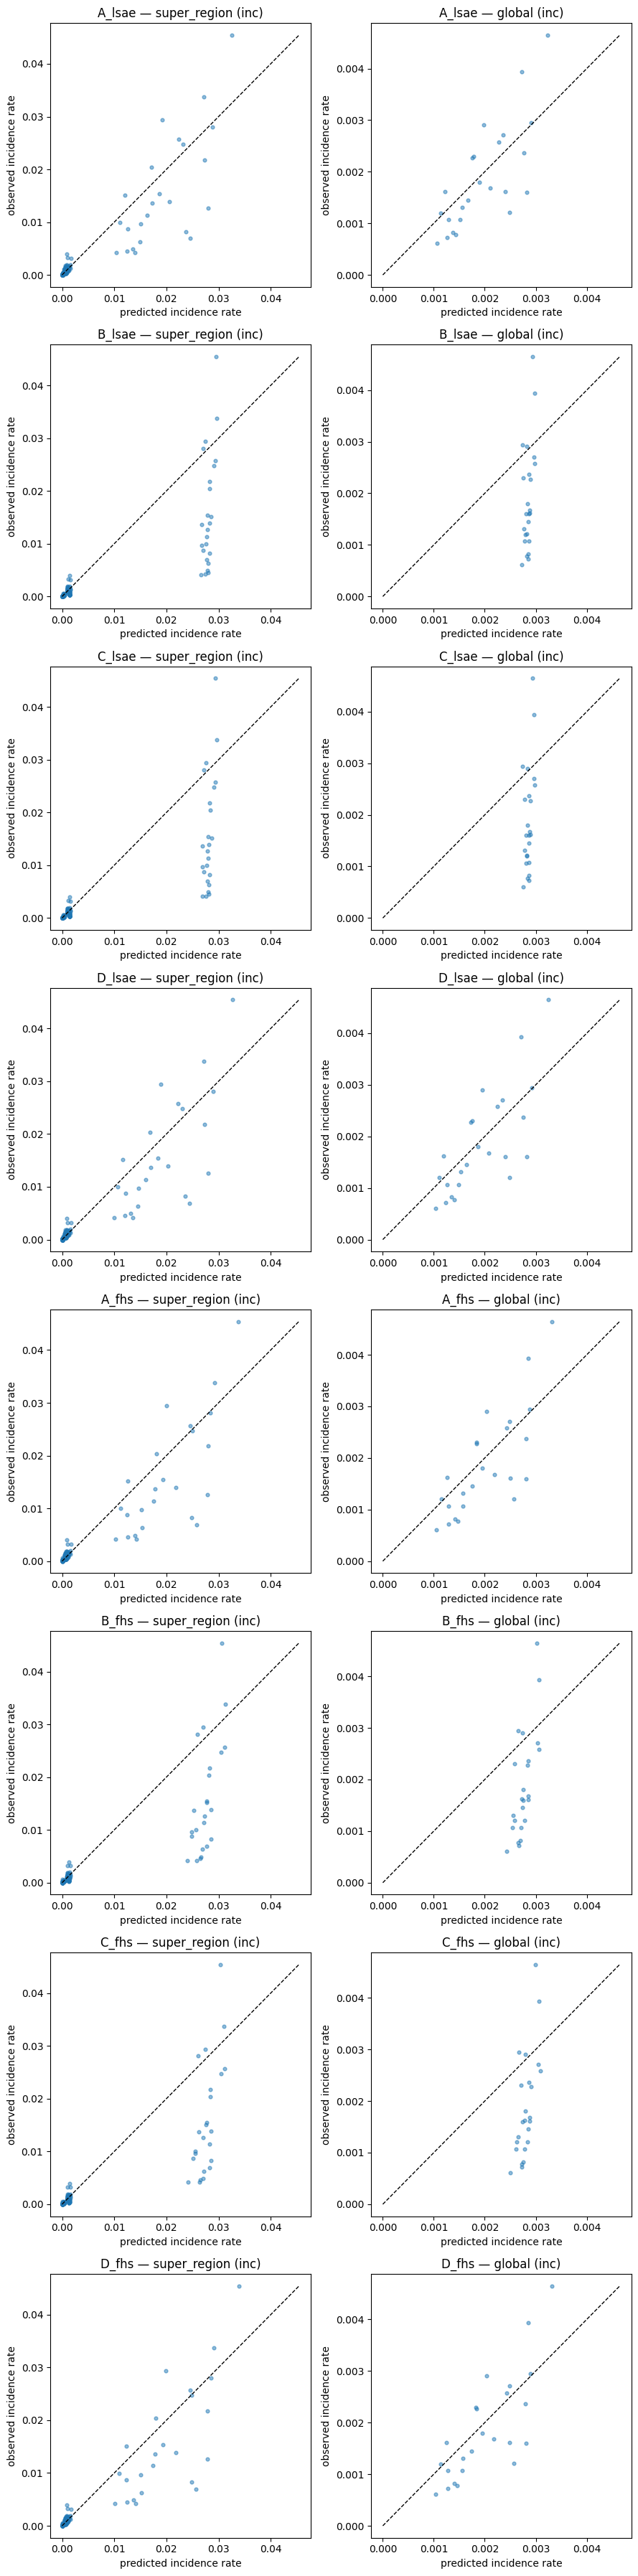

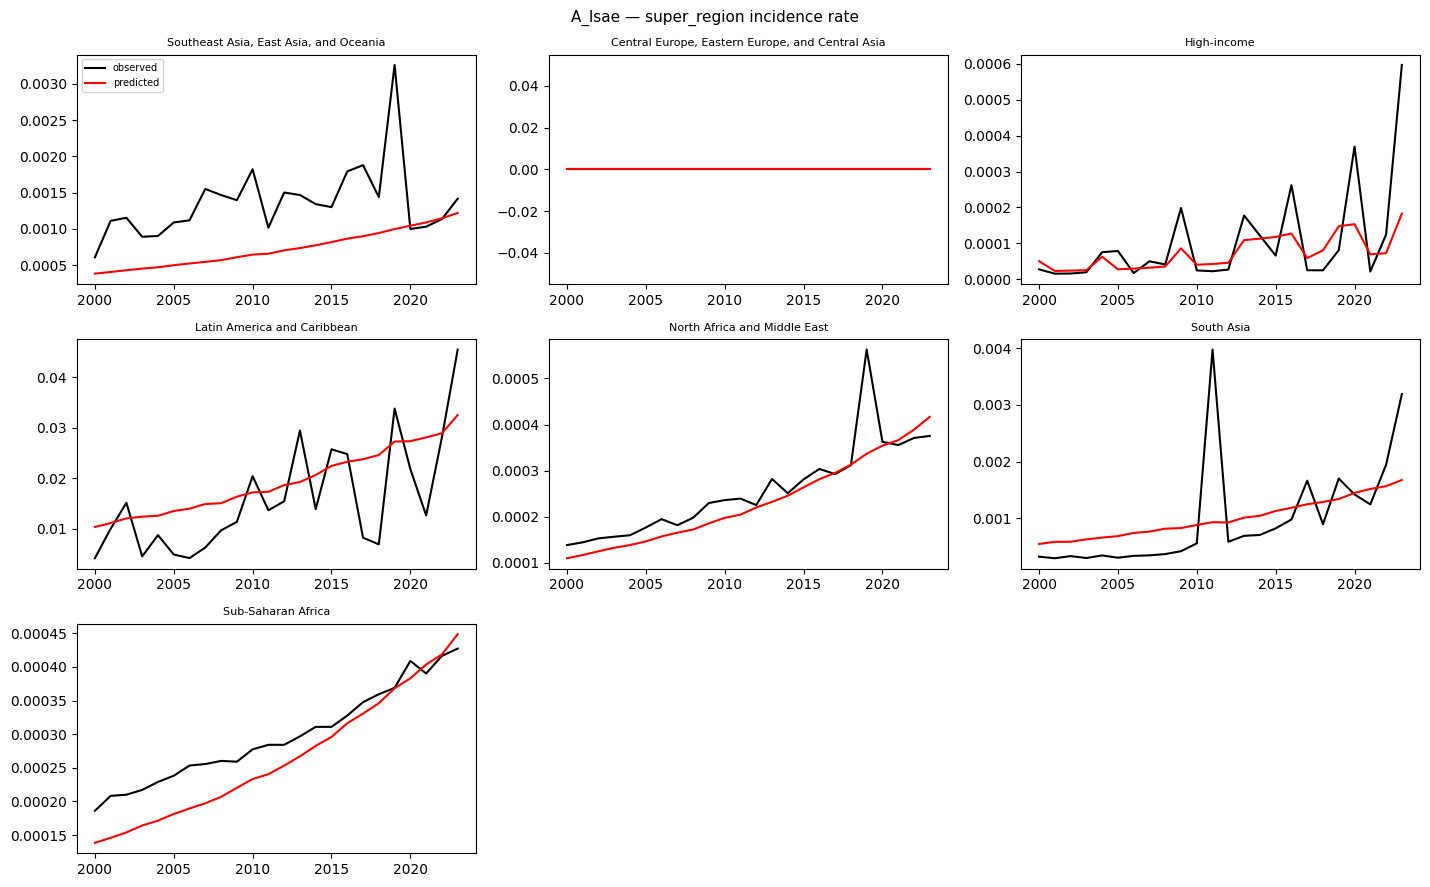

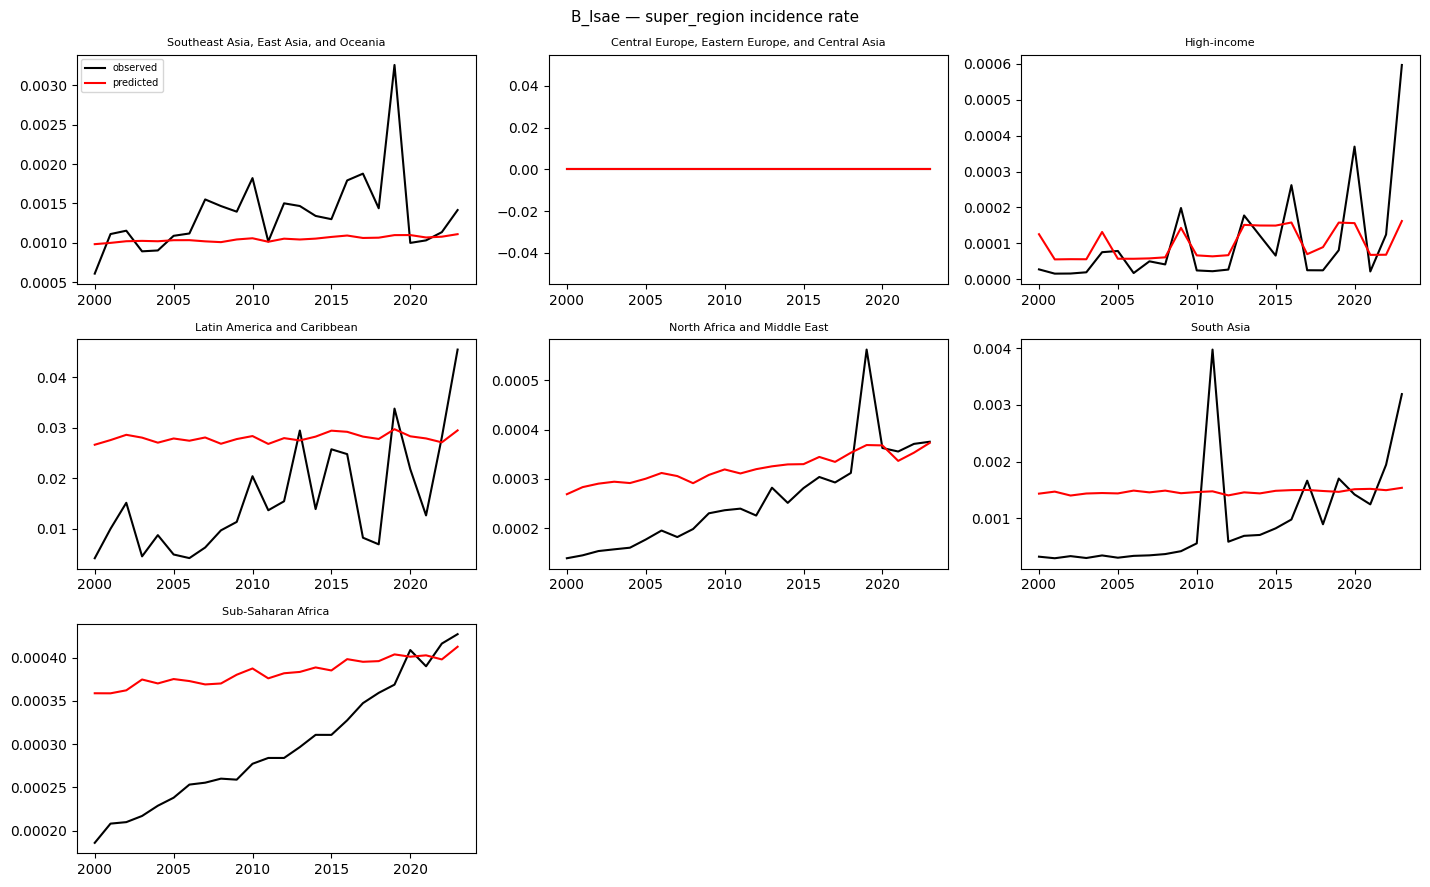

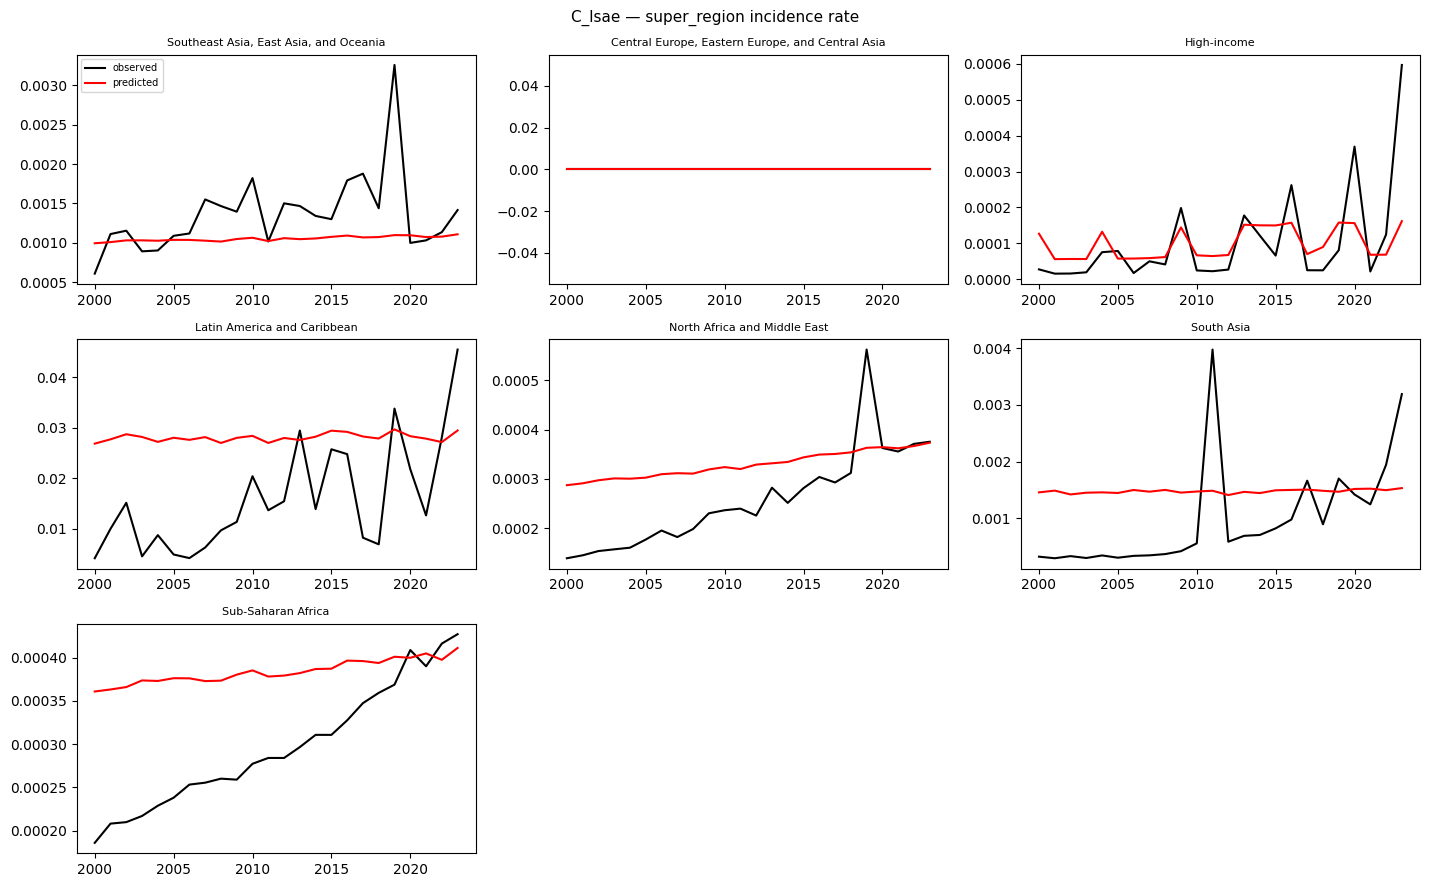

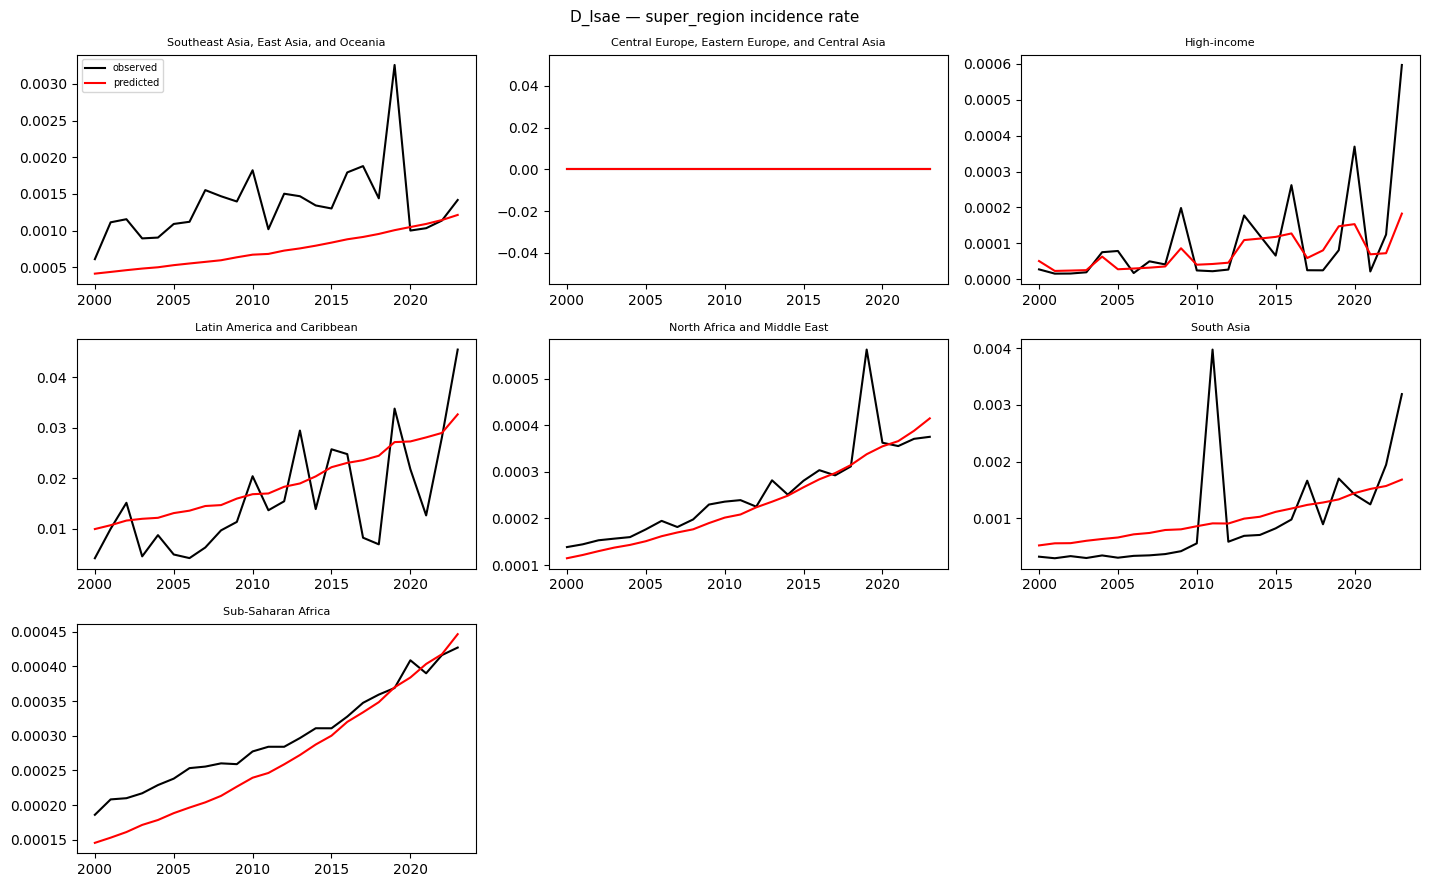

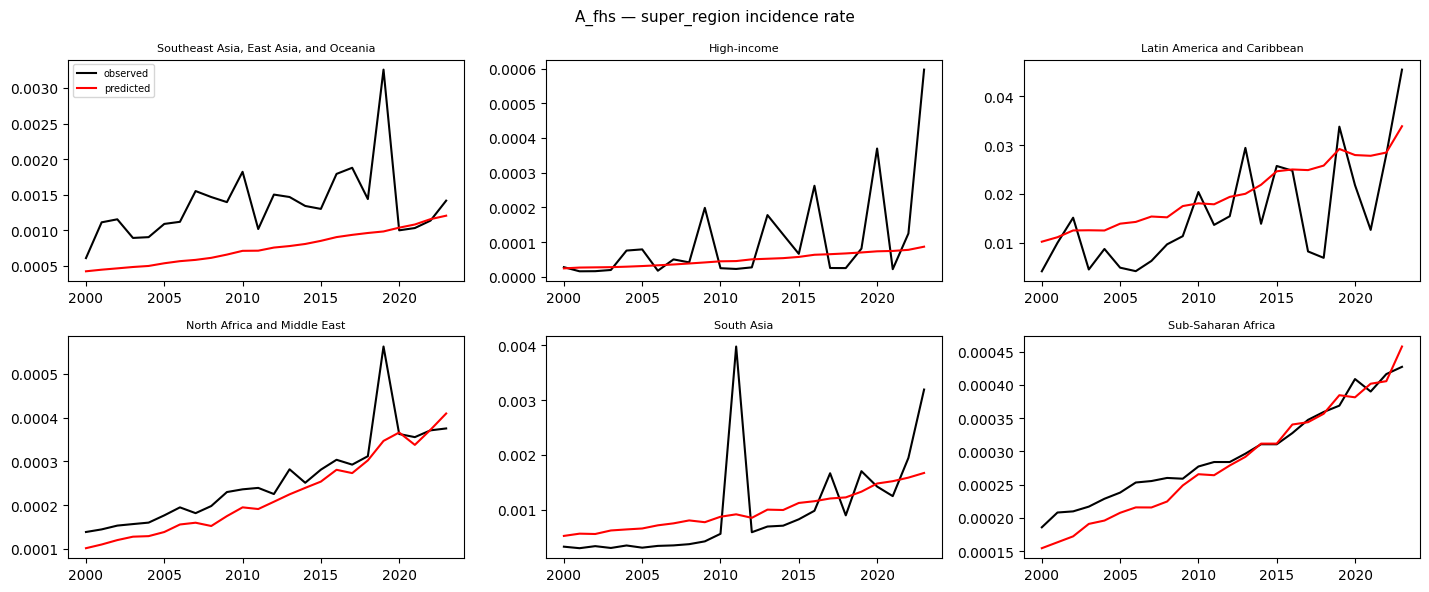

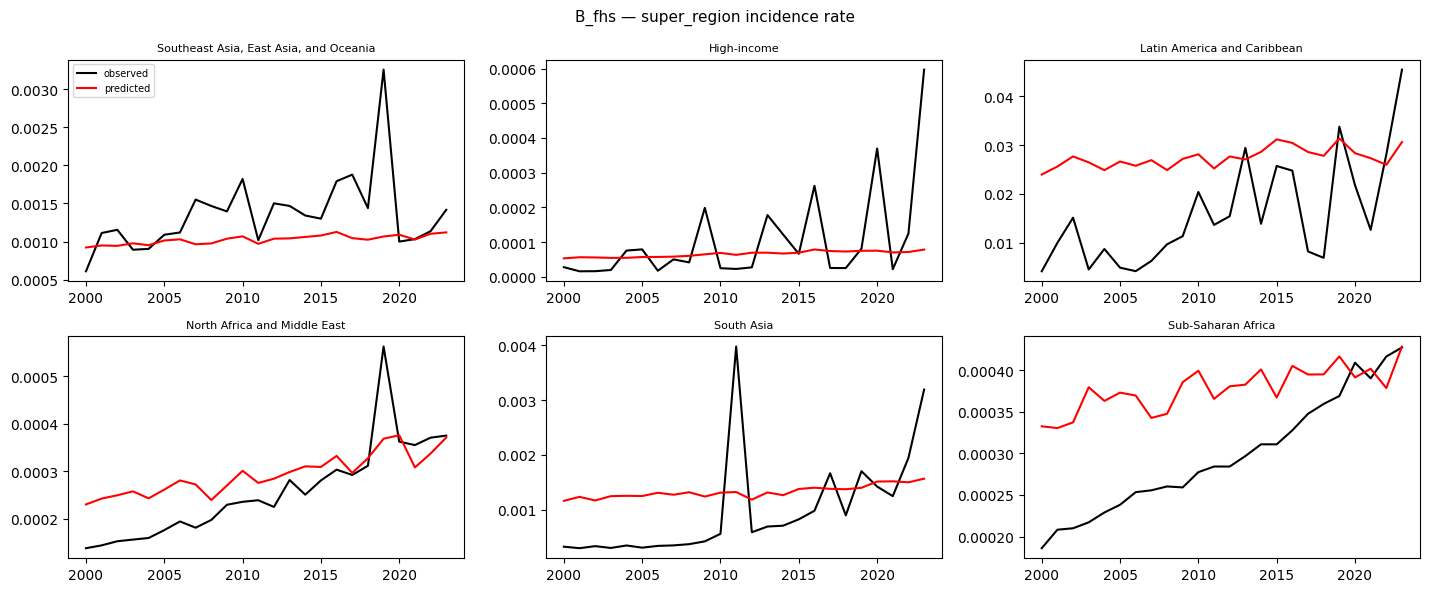

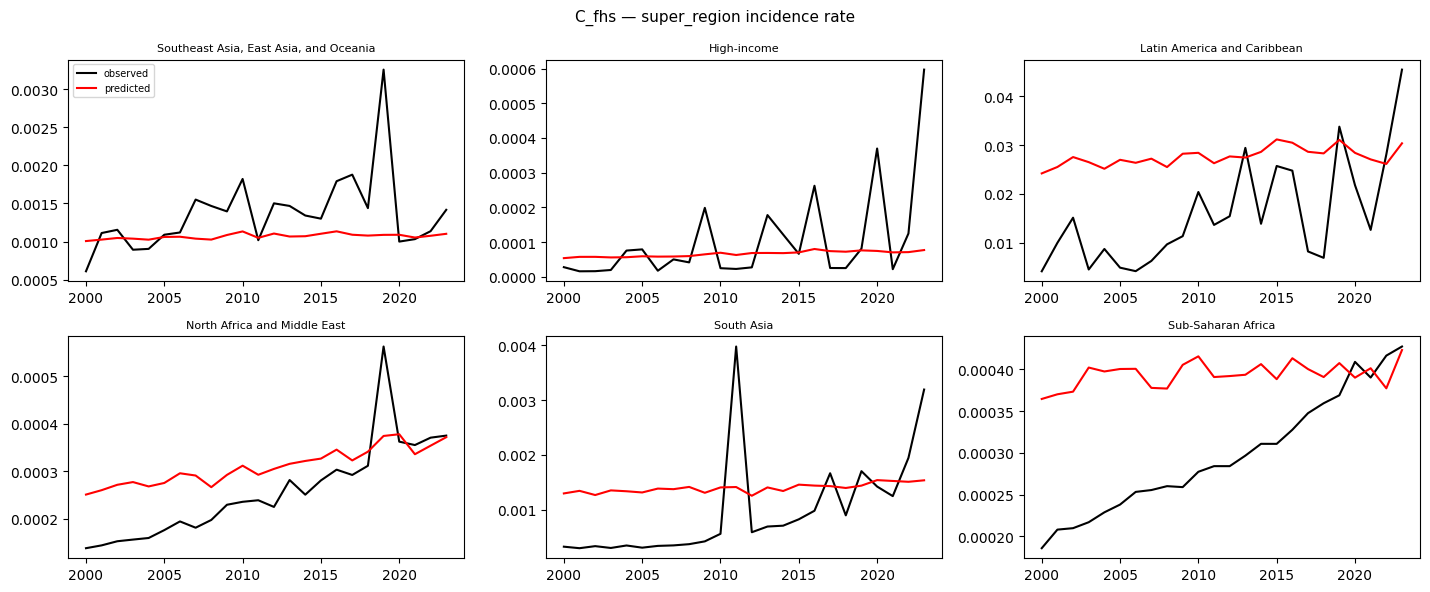

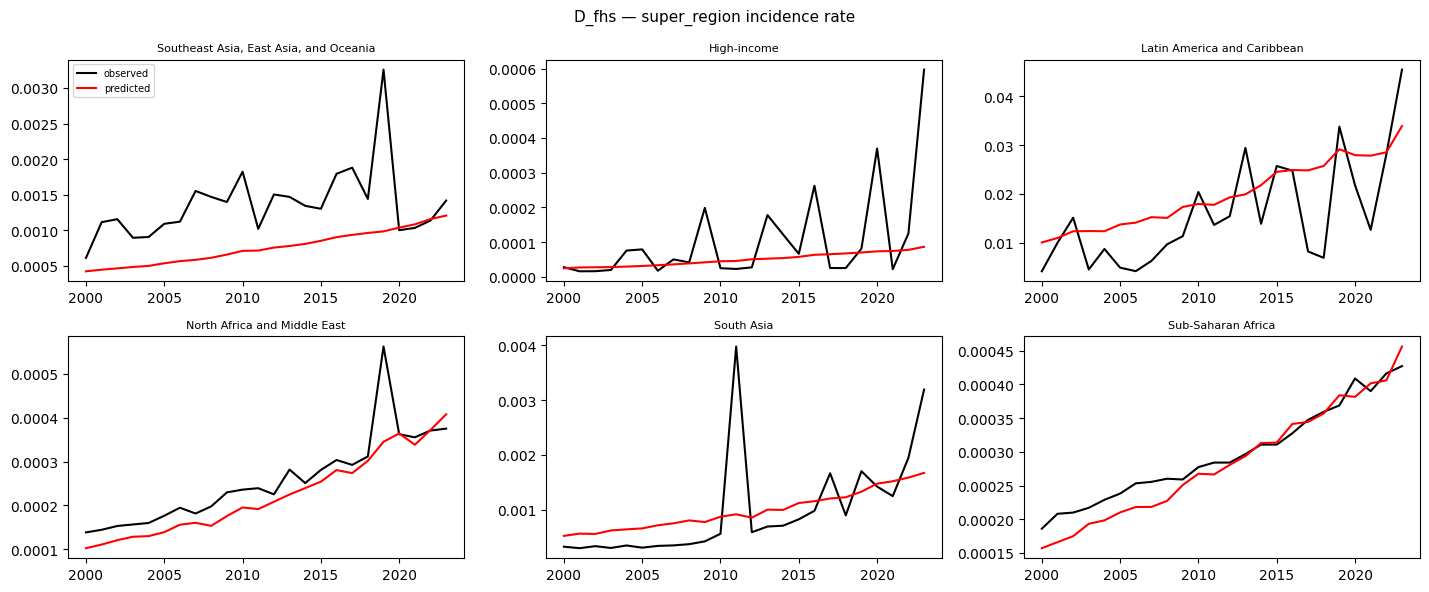

In [ ]:
MEAS_LABEL = {"inc": "incidence rate", "mort": "mortality rate", "cfr": "CFR"}


def plot_scatter(res, level, measure="inc", ax=None):
    """Aggregated obs-vs-pred `measure` at `level` (all locations × years), with y=x."""
    pcol, ocol = VALIDATE_MEASURES[measure]
    d = res["merged"][res["merged"].level == level].dropna(subset=[ocol, pcol])
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(d[pcol], d[ocol], s=12, alpha=0.5)
    hi = float(max(d[ocol].max(), d[pcol].max())) if len(d) else 1.0
    ax.plot([0, hi], [0, hi], "k--", lw=1)
    ax.set(xlabel=f"predicted {MEAS_LABEL[measure]}", ylabel=f"observed {MEAS_LABEL[measure]}",
           title=f"{res['name']} — {LEVEL_NAME[level]} ({measure})")
    return ax


def plot_timeseries(res, level, measure="inc", ncol=3):
    """Per-location observed vs predicted `measure` time series at `level` (small multiples)."""
    pcol, ocol = VALIDATE_MEASURES[measure]
    d = res["merged"][res["merged"].level == level].dropna(subset=[ocol, pcol])
    locs = sorted(d.location_id.unique())
    nrow = -(-len(locs) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.8 * ncol, 3.0 * nrow), squeeze=False)
    for ax, loc in zip(axes.flat, locs):
        dd = d[d.location_id == loc].sort_values("year_id")
        ax.plot(dd.year_id, dd[ocol], "k-", label="observed")
        ax.plot(dd.year_id, dd[pcol], "r-", label="predicted")
        ax.set_title(str(h.loc[loc, "location_name"]), fontsize=8)
    for ax in axes.flat[len(locs):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=7)
    fig.suptitle(f"{res['name']} — {LEVEL_NAME[level]} {MEAS_LABEL[measure]}", fontsize=11)
    fig.tight_layout()
    return fig


# INCIDENCE: super-region (level 1) + global (level 0) obs-vs-pred scatter, one row per formulation
fig, axes = plt.subplots(len(results), 2, figsize=(9, 4.5 * len(results)), squeeze=False)
for row, res in zip(axes, results.values()):
    plot_scatter(res, level=1, measure="inc", ax=row[0])
    plot_scatter(res, level=0, measure="inc", ax=row[1])
fig.tight_layout()

# per-super-region incidence time series for each formulation
for res in results.values():
    plot_timeseries(res, level=1, measure="inc");

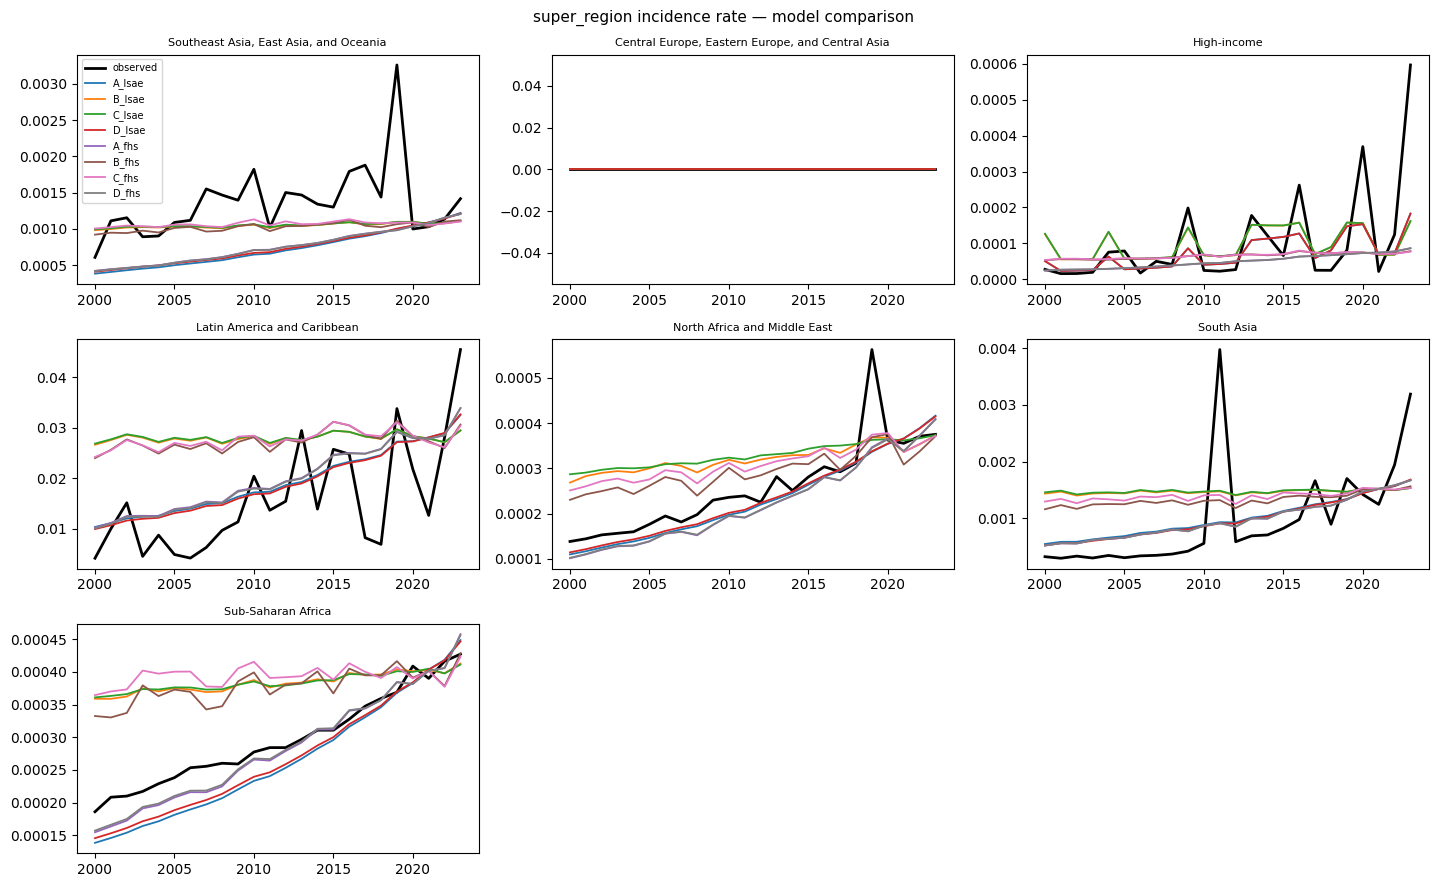

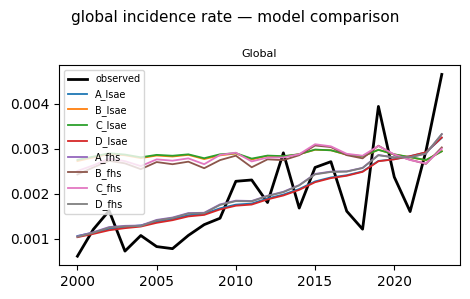

In [ ]:
def plot_timeseries_compare(results, level=1, measure="inc", location_ids=None, names=None, ncol=3):
    """Observed (once, black) + each model's predicted `measure` overlaid per location panel.

    `names` selects which formulations to overlay (default: all in `results`). Observed is
    identical across models, so it is drawn once from the first model that covers a panel.
    """
    pcol, ocol = VALIDATE_MEASURES[measure]
    names = list(results) if names is None else names
    colors = plt.cm.tab10.colors

    # union of locations at this level across the selected models
    if location_ids is not None:
        locs = sorted(set(location_ids))
    else:
        locs = sorted(set().union(*[
            set(results[nm]["merged"].loc[results[nm]["merged"].level == level, "location_id"].unique())
            for nm in names
        ]))
    nrow = -(-len(locs) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.8 * ncol, 3.0 * nrow), squeeze=False)
    for ax, loc in zip(axes.flat, locs):
        obs_drawn = False
        for j, nm in enumerate(names):
            m = results[nm]["merged"]
            d = m[(m.level == level) & (m.location_id == loc)].sort_values("year_id")
            if d.empty:
                continue
            if not obs_drawn:
                ax.plot(d.year_id, d[ocol], "k-", lw=2, label="observed")
                obs_drawn = True
            ax.plot(d.year_id, d[pcol], color=colors[j % 10], lw=1.3, label=nm)
        ax.set_title(str(h.loc[loc, "location_name"]), fontsize=8)
    for ax in axes.flat[len(locs):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=7)
    fig.suptitle(f"{LEVEL_NAME[level]} {MEAS_LABEL[measure]} — model comparison", fontsize=11)
    fig.tight_layout()
    return fig


# all formulations overlaid per super-region panel; pass names=[...] to pick a subset,
# measure="mort"/"cfr" to switch outcome
plot_timeseries_compare(results, level=1, measure="inc")
plot_timeseries_compare(results, level=0, measure="inc", ncol=1);

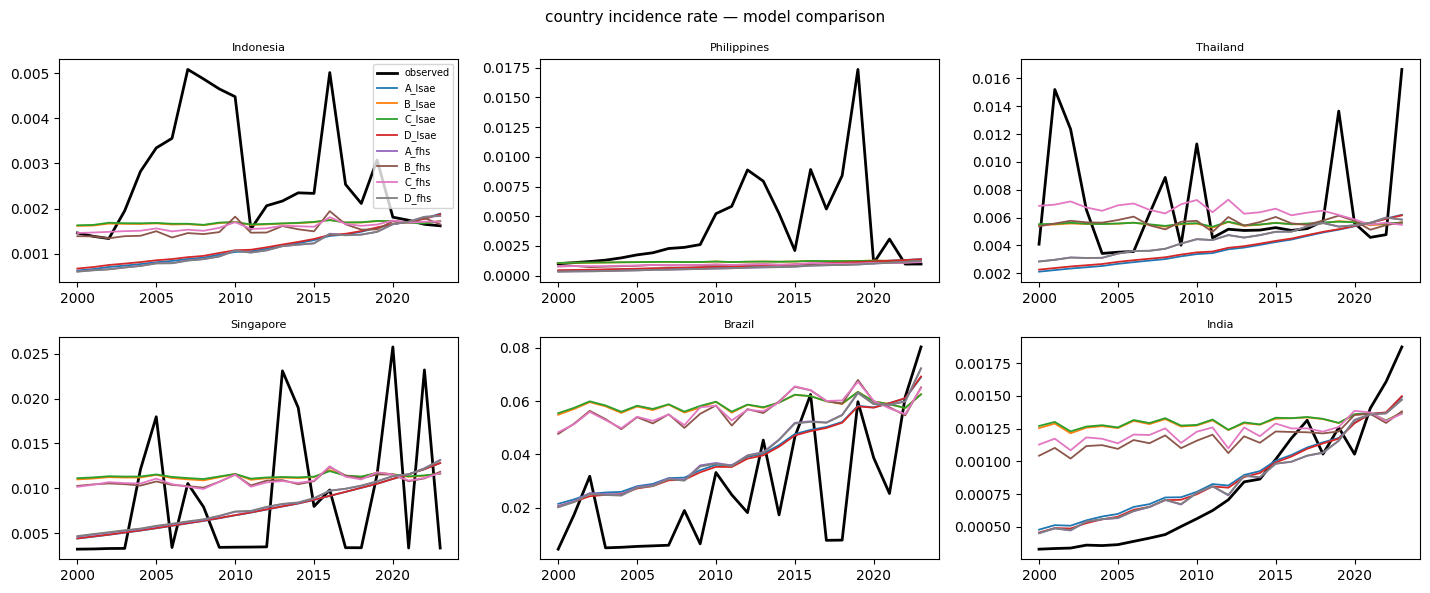

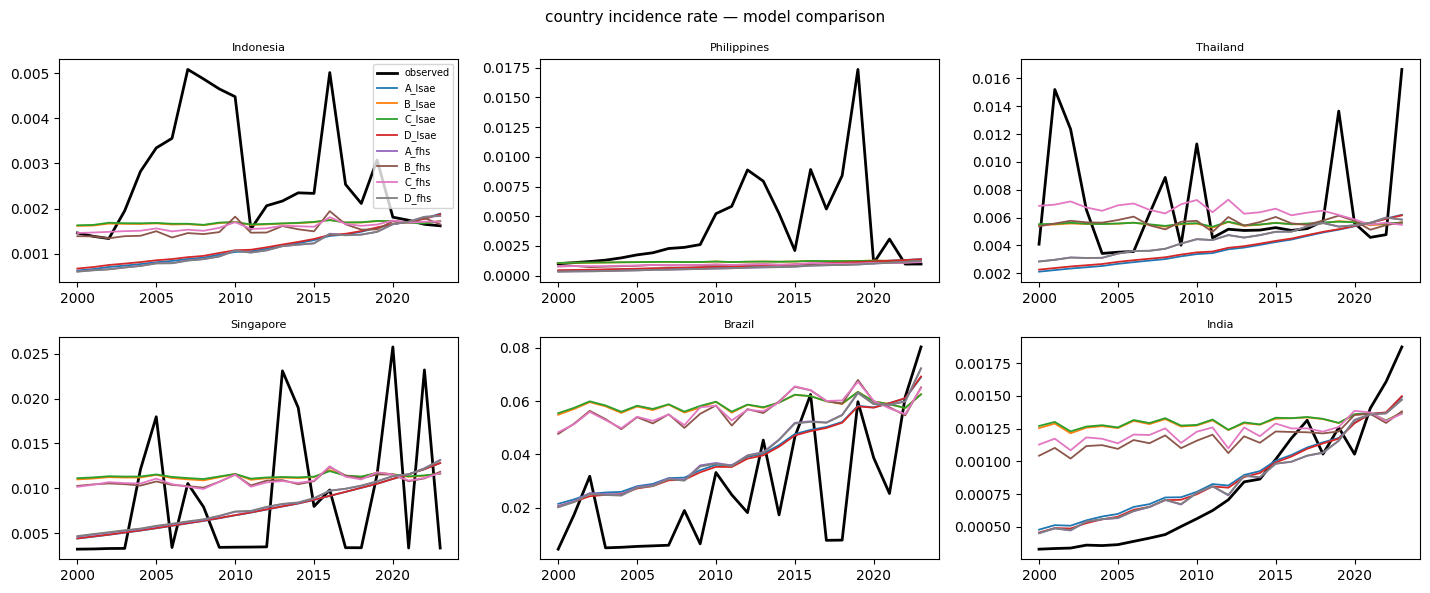

In [ ]:
plot_timeseries_compare(results, level = 3, location_ids = hierarchy_df[hierarchy_df['location_name'].isin([
    'Brazil', 'India', 'Indonesia', 'Thailand', 'Philippines', 'Singapore'])].location_id.tolist())

## Mortality via CFR (with the intermediate CFR diagnostic)

The full outcome chain: **incidence** (above) → **CFR** (the intermediate, `mort = inc × cfr`)
→ **mortality**. The CFR panels are the diagnostic that explains any mortality miss — a
mortality error is either an incidence error or a CFR error, and separating them here says
which. All three use the same aggregated, count-space, full-population-denominator machinery;
only the measure changes (`plot_scatter` / `plot_timeseries_compare` take `measure=`).

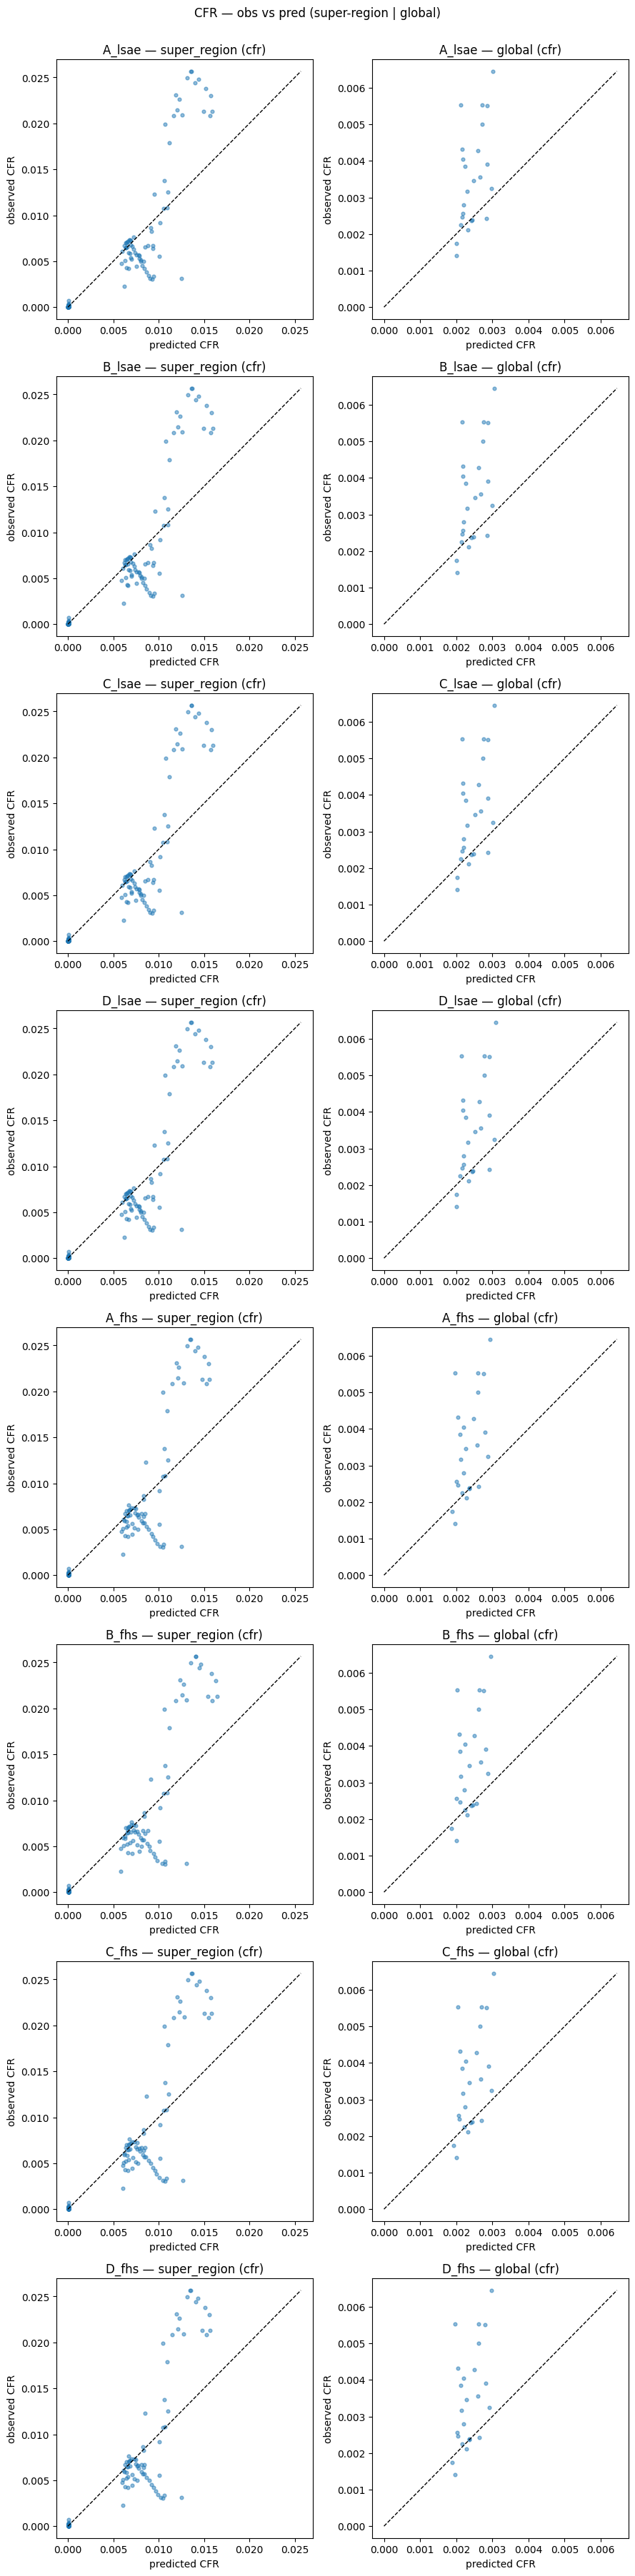

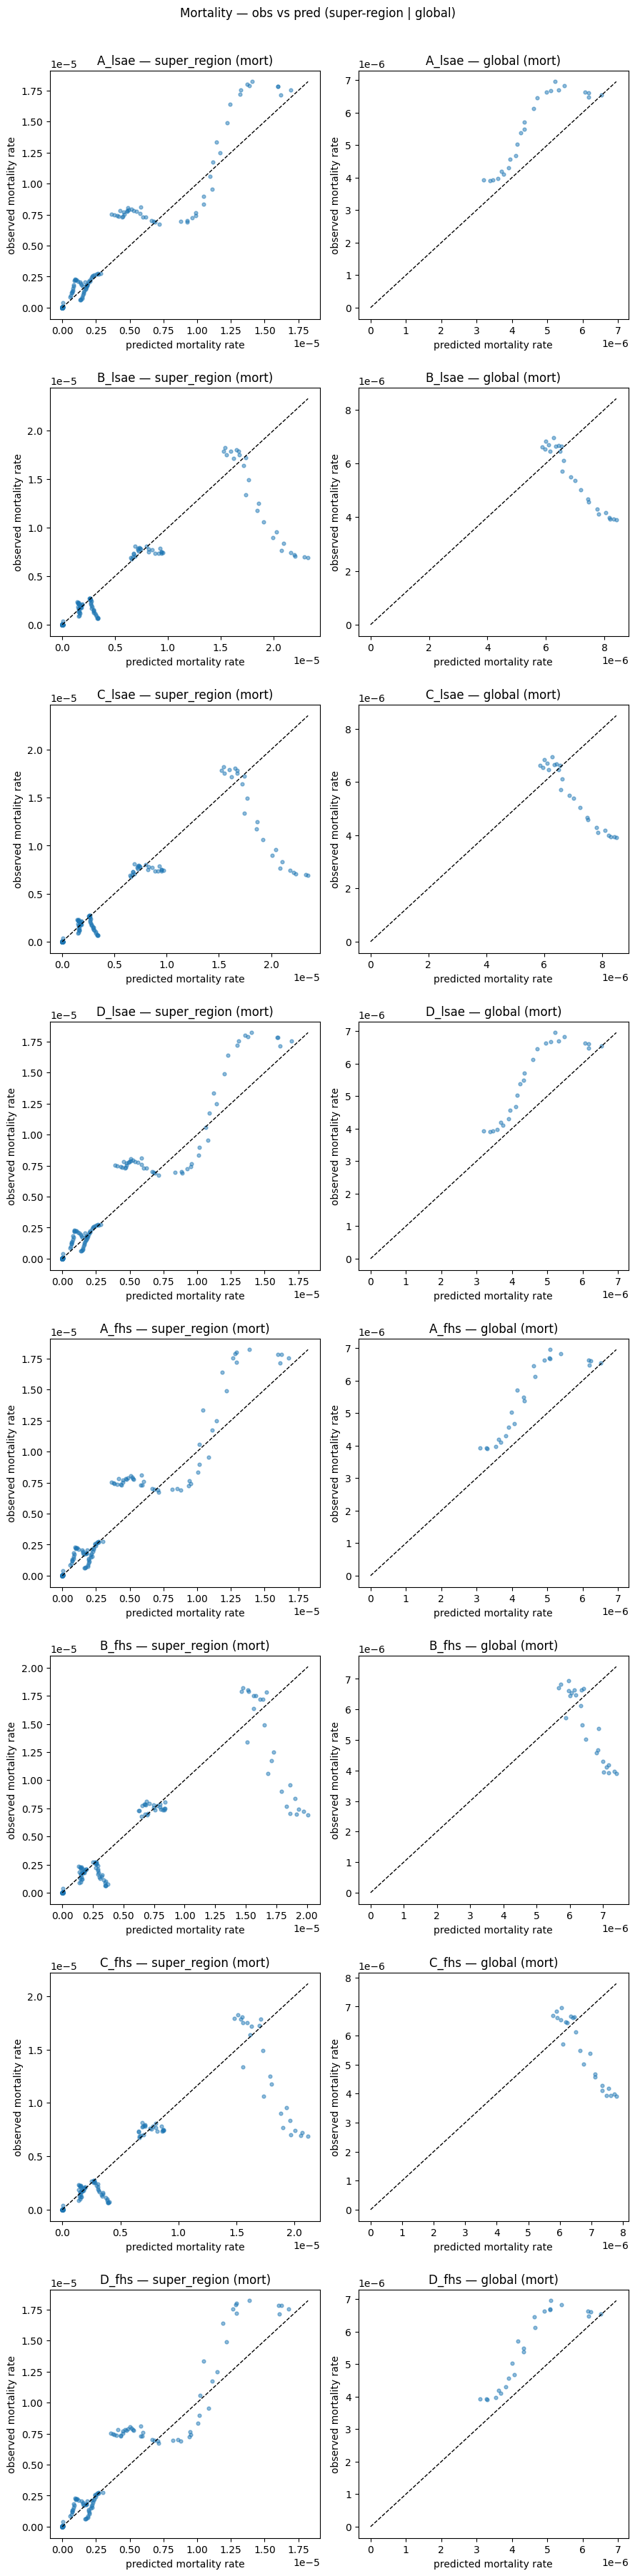

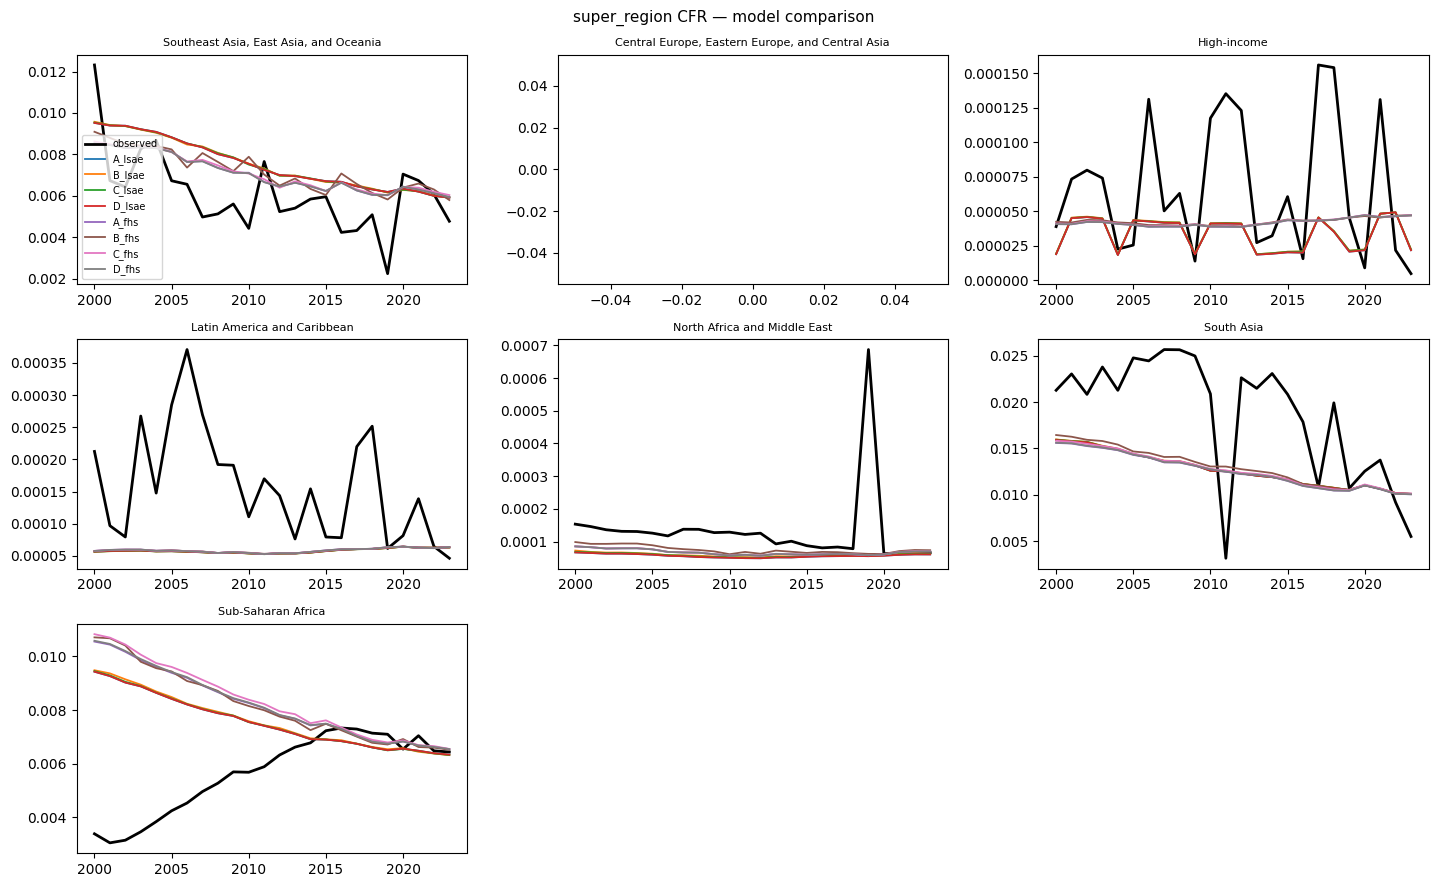

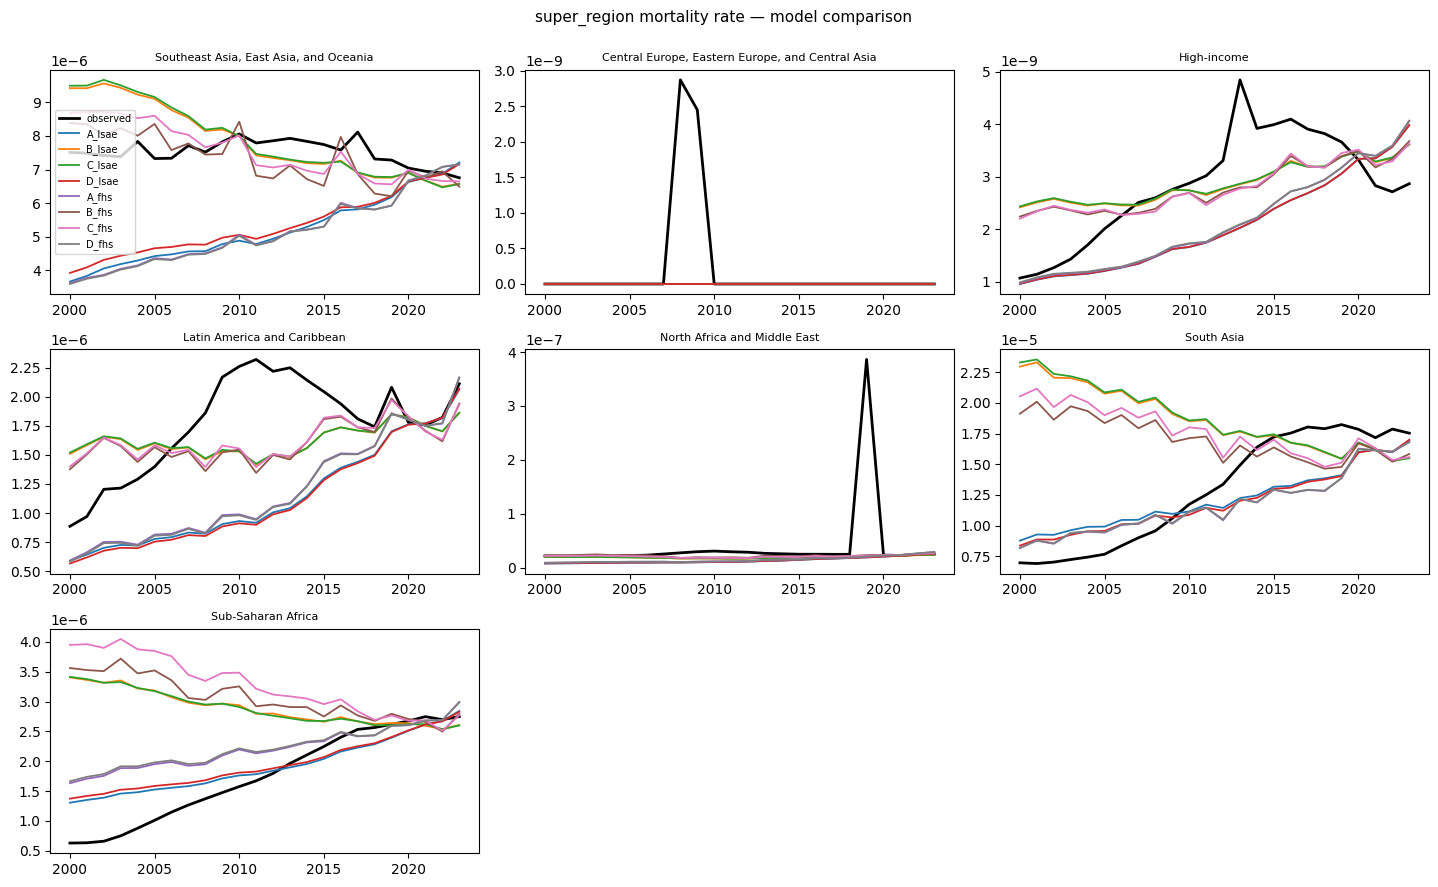

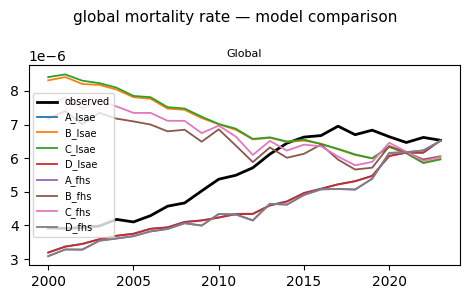

In [ ]:
# CFR diagnostic (intermediate) — obs-vs-pred CFR scatter at super-region (1) + global (0)
fig, axes = plt.subplots(len(results), 2, figsize=(9, 4.5 * len(results)), squeeze=False)
for row, res in zip(axes, results.values()):
    plot_scatter(res, level=1, measure="cfr", ax=row[0])
    plot_scatter(res, level=0, measure="cfr", ax=row[1])
fig.suptitle("CFR — obs vs pred (super-region | global)", y=1.001)
fig.tight_layout()

# MORTALITY — obs-vs-pred scatter at super-region (1) + global (0)
fig, axes = plt.subplots(len(results), 2, figsize=(9, 4.5 * len(results)), squeeze=False)
for row, res in zip(axes, results.values()):
    plot_scatter(res, level=1, measure="mort", ax=row[0])
    plot_scatter(res, level=0, measure="mort", ax=row[1])
fig.suptitle("Mortality — obs vs pred (super-region | global)", y=1.001)
fig.tight_layout()

# model-comparison time series: CFR then mortality, per super-region + global
plot_timeseries_compare(results, level=1, measure="cfr")
plot_timeseries_compare(results, level=1, measure="mort")
plot_timeseries_compare(results, level=0, measure="mort", ncol=1);

# Forecast to 2100 (out-of-sample trajectories)

Vet each model by how sane its forecast is. For each SSP × draw we predict the base-group
incidence rate **and** CFR on the **future** covariates (from
`08b_build_dengue_forecast_inputs.py`), carry **each location's past shift forward** (the same
per-location anchor shift used in-sample — exactly what `04_forecasting` does at the rake year),
convert to admin-2 counts, aggregate up in count space, and divide by the future population.
Then median + 95% band across draws, per SSP, overlaid on the in-sample fit so you see the
in-sample → OOS transition on one axis.

**Efficiency — the age/sex collapse.** The all-age admin-2 incidence count is
`exp(base_log_shifted) × Σ_as(population × rr_inc_as)`. With the age/sex structure held at
`RAKE_YEAR`, `w_inc[loc] = Σ_as(pop × rr)` is a **per-location scalar** — the exact
factorization of `broadcast_to_as_counts`, so the forecast needs no age/sex rows at all
(`mort_count = inc_count × cfr`). That turns a ~112M-row/draw broadcast into a
~2.2M-row/draw predict.

**Two simplifications (deliberate — these are what the notebook exists to expose):**
1. **Age/sex structure (rr + population) held at `RAKE_YEAR`.** A real forecaster would use
   future age/sex population. Here it collapses into `w_inc` and the future all-age denominator
   still moves (population file spans 2000–2100).
2. **Forecast location set = fit base locations ∩ 08b prediction locations, at the lsae
   (admin-2) grain** — the 08b inputs are admin-2, so fhs-grain formulations aren't forecast
   here (they'd aggregate admin-2 covariates up first).

In [ ]:
import xarray as xr

# ── forecast config ───────────────────────────────────────────────────────────
FORECAST_SSPS    = ["ssp245"]          # add "ssp126","ssp585" once it looks right
N_FORECAST_DRAWS = 5                    # draws are ~free after the read; raise toward 100
FORECAST_YEARS_FC = list(range(RAKE_YEAR + 1, RAKE_YEAR + 11))   # 2024–2033 (decade, annual)
#   full annual: list(range(RAKE_YEAR + 1, 2101))   |   every 5th: sorted(set(range(RAKE_YEAR+1,2101,5))|{2100})
FORECAST_INPUTS   = mbpc.DEN_FORECAST_INPUTS_READ_PATH
FORECAST_LEVELS   = (0, 1, 3)           # global, super-region, country

# Each formulation forecasts at ITS OWN grain (res["grain"]). 08b inputs are admin-2 (lsae); for
# fhs formulations we roll the admin-2 covariates up to fhs pop-weighted (verified to reproduce the
# past fhs covariates to ~1e-16, i.e. the same roll-up 06b did). w_inc / pw / cfr_shift are keyed
# by location_id, so they already cover both grains from past_base.

_A0_CODE = {a0: i for i, a0 in enumerate(
    past_base["A0_location_id"].astype("category").cat.categories)}
_BASE_AS_ID = int(past_base[(past_base.age_group_id == REFERENCE_AGE_GROUP_ID)
                            & (past_base.sex_id == REFERENCE_SEX_ID)]["as_id"].iloc[0])
_pw = (past_base[past_base.year_id == RAKE_YEAR]
       .assign(pw=lambda d: d.population * d.rr_inc_as)[["location_id", "age_group_id", "sex_id", "pw"]])
_w_inc = _pw.groupby("location_id")["pw"].sum()
_a2_pop = population_df[["location_id", "year_id", "population"]]   # roll-up weights (admin-2 rows)

_URBAN_RAW = "weighted_1km_urban_threshold_300.0_simple_mean"
_RAW_COVS  = ["dengue_suitability", "relative_humidity", _URBAN_RAW, "gdppc_mean",
              "people_flood_days_per_capita"]
_arr_cache, _shift_cache, _mw_cache = {}, {}, {}


def _load_ssp_arrays(ssp, years):
    """Read the 08b covariate arrays for `ssp`+`years` into numpy ONCE (cached). The nc is chunked
    with all 100 draws per chunk, so one draw costs the same as all — read all, slice in memory."""
    key = (ssp, tuple(years))
    if key not in _arr_cache:
        with xr.open_dataset(FORECAST_INPUTS / f"dengue_forecast_inputs_{ssp}.nc") as ds:
            suit = ds["dengue_suitability"].sel(year_id=years).values
            hum  = ds["relative_humidity"].sel(year_id=years).values
            scal = {v: ds[v].sel(year_id=years).values
                    for v in [_URBAN_RAW, "gdppc_mean", "people_flood_days_per_capita"]}
            locs = ds["location_id"].values.astype("int64")
        _arr_cache[key] = (suit, hum, scal, locs)
    return _arr_cache[key]


def _rollup_to_fhs(a2, value_cols):
    """Pop-weighted roll-up of an admin-2 covariate frame -> fhs (matches 06b to ~1e-16)."""
    m = a2.merge(_a2_pop, on=["location_id", "year_id"], how="left")
    m["_fhs"] = m["location_id"].map(h["fhs_location_id"])
    m = m.dropna(subset=["_fhs", "population"])
    for c in value_cols:
        m[c] = m[c] * m["population"]
    g = m.groupby(["_fhs", "year_id"], as_index=False).agg(
        {**{c: "sum" for c in value_cols}, "population": "sum"})
    for c in value_cols:
        g[c] = g[c] / g["population"]
    return g.rename(columns={"_fhs": "location_id"}).drop(columns="population")


def _grain_covariates(ssp, draw, years, grain):
    """Per-(loc, year) RAW covariate frame at `grain` for one draw: admin-2 straight from 08b, or
    rolled up to fhs (pop-weighted)."""
    suit, hum, scal, locs = _load_ssp_arrays(ssp, years)
    yrs = np.asarray(years)
    LL, YY = np.meshgrid(locs, yrs, indexing="ij")
    a2 = pd.DataFrame({"location_id": LL.ravel(), "year_id": YY.ravel(),
                       "dengue_suitability": suit[:, :, draw].ravel(),
                       "relative_humidity":  hum[:, :, draw].ravel(),
                       _URBAN_RAW: scal[_URBAN_RAW].ravel(),
                       "gdppc_mean": scal["gdppc_mean"].ravel(),
                       "people_flood_days_per_capita": scal["people_flood_days_per_capita"].ravel()})
    return _rollup_to_fhs(a2, _RAW_COVS) if grain == "fhs" else a2


def _derive(df):
    """Add the model's derived/feature columns to a raw-covariate frame."""
    df = df.copy()
    df["urban_fraction"]  = np.clip(df[_URBAN_RAW].astype(float), 1e-3, 1 - 1e-3)
    df["log_gdppc_mean"]  = np.log(df["gdppc_mean"].astype(float))
    df["A0_af"]           = df["location_id"].map(h["A0_location_id"]).map(_A0_CODE)
    df["super_region_id"] = df["location_id"].map(h["super_region_id"])
    for sr in SR_IDS:
        df[f"year_sr_{int(sr)}"] = np.where(df["super_region_id"] == sr, df["year_id"], 0.0)
    return df.dropna(subset=["A0_af"])


def future_frame(ssp, draw, years, location_ids, grain):
    """One draw's future incidence covariate frame at `grain`, restricted to `location_ids`."""
    df = _grain_covariates(ssp, draw, years, grain)
    return _derive(df[df.location_id.isin(location_ids)])


def compute_location_shift(gam, spec, grain, fit_frame, response_col,
                           mode=ANCHOR_MODE, anchor_years=ANCHOR_YEARS):
    """Incidence per-location shift from the PAST anchor window at `grain` — obs (fit_frame) and
    pred (grain_frame) are both at the model's own grain, so their location_ids align."""
    frame = grain_frame(grain)
    seen = set(fit_frame["A0_af"].unique())
    base_rows = frame[(frame.age_group_id == REFERENCE_AGE_GROUP_ID)
                      & (frame.sex_id == REFERENCE_SEX_ID) & (frame.A0_af.isin(seen))]
    pred = _predict_model_space(gam, spec, base_rows)
    years = (RAKE_YEAR,) if mode == "point" else tuple(anchor_years)
    obs_win = (fit_frame[fit_frame.year_id.isin(years)]
               [["location_id", "year_id", response_col]].rename(columns={response_col: "obs_base"}))
    pred_win = pred[pred.year_id.isin(years)][["location_id", "year_id", "base_pred"]]
    return _anchor_shift(obs_win, pred_win, mode)


def _shifts_for(name, grain, res):
    """Cache the INCIDENCE per-location shift for a formulation at ITS grain."""
    if name not in _shift_cache:
        spec = next(f["spec"] for f in FORMULATIONS if f["name"] == name)
        _shift_cache[name] = compute_location_shift(res["gam_inc"], spec, grain, res["fit_frame"],
                                                    "log_dengue_inc_rate")
    return _shift_cache[name]


def cfr_mort_weight(ssp, location_ids, years, grain):
    """Per-(loc, year) mortality weight at `grain`: Σ_as pw × cfr_as. CFR has no draw-varying
    covariate (gdppc deterministic) -> computed ONCE per (ssp, grain), not per draw. See the
    module notes for the faithful (full age/sex expansion) vs this cheap route."""
    key = (ssp, tuple(years), grain)
    if key not in _mw_cache:
        gam, off = cfr_model()
        sh = cfr_shift(gam, off, grain)
        suit, hum, scal, locs = _load_ssp_arrays(ssp, years)
        yrs = np.asarray(years)
        LL, YY = np.meshgrid(locs, yrs, indexing="ij")
        a2 = pd.DataFrame({"location_id": LL.ravel(), "year_id": YY.ravel(),
                           "gdppc_mean": scal["gdppc_mean"].ravel()})
        base = _rollup_to_fhs(a2, ["gdppc_mean"]) if grain == "fhs" else a2
        base = base[base.location_id.isin(location_ids)].copy()
        base["log_gdppc_mean"] = np.log(base["gdppc_mean"].astype(float))
        base["A0_af"] = base["location_id"].map(h["A0_location_id"]).map(_A0_CODE)
        base = base.dropna(subset=["A0_af"])
        base["as_id"] = _BASE_AS_ID
        bp = _predict_model_space(gam, cfr_spec, base).rename(columns={"base_pred": "base_logit_cfr"})
        pw = _pw[_pw.location_id.isin(location_ids)]
        ex = bp.merge(pw, on="location_id", how="inner")
        ex["off"] = ex.set_index(["age_group_id", "sex_id"]).index.map(off).to_numpy()
        ex["sh"]  = ex.set_index(["location_id", "age_group_id", "sex_id"]).index.map(sh).to_numpy()
        ex["cfr_as"] = expit(ex["base_logit_cfr"] + ex["off"] + ex["sh"])
        ex.loc[ex["sh"].isna(), "cfr_as"] = 0.0
        ex["mw"] = ex["pw"] * ex["cfr_as"]
        _mw_cache[key] = ex.groupby(["location_id", "year_id"])["mw"].sum()
    return _mw_cache[key]


_LEVEL_KEY = {1: "super_region_id", 3: "A0_location_id"}   # 0 == global


def _agg_forecast(aa, levels=FORECAST_LEVELS):
    """SLIM count-space aggregation to global/SR/country (direct groupby, full-pop denominator).
    Grain-agnostic: any grain's location_id maps to its SR/A0 ancestor."""
    cc = ["dengue_inc_count_pred", "dengue_mort_count_pred"]
    a = aa.copy()
    for lvl, key in _LEVEL_KEY.items():
        a[f"_L{lvl}"] = a["location_id"].map(h[key])
    parts = []
    for lvl in levels:
        if lvl == 0:
            g = a.groupby("year_id")[cc].sum().reset_index(); g["location_id"] = 1
        else:
            k = f"_L{lvl}"
            g = (a.dropna(subset=[k]).groupby([k, "year_id"])[cc].sum().reset_index()
                 .rename(columns={k: "location_id"}))
            g["location_id"] = g["location_id"].astype("int64")
        parts.append(g)
    full = (pd.concat(parts, ignore_index=True)
            .merge(population_df[["location_id", "year_id", "population"]],
                   on=["location_id", "year_id"], how="left"))
    full["dengue_inc_rate_pred"]  = full["dengue_inc_count_pred"]  / full["population"]
    full["dengue_mort_rate_pred"] = full["dengue_mort_count_pred"] / full["population"]
    full["dengue_cfr_pred"]       = full["dengue_mort_rate_pred"]  / full["dengue_inc_rate_pred"]
    return full[["location_id", "year_id", "dengue_inc_rate_pred",
                 "dengue_mort_rate_pred", "dengue_cfr_pred"]]


def forecast_pred(res, fut, shift_inc, mort_weight, levels=FORECAST_LEVELS):
    """Incidence via w_inc collapse; mortality via the per-(loc,year) age/sex-CFR mort_weight."""
    spec = next(f["spec"] for f in FORMULATIONS if f["name"] == res["name"])
    pi = _predict_model_space(res["gam_inc"], spec, fut)
    pi["base_log_shifted"] = pi["base_pred"] + pi["location_id"].map(shift_inc)
    pi = pi.dropna(subset=["base_log_shifted"])
    pi["_inc"] = np.exp(pi["base_log_shifted"])
    pi["dengue_inc_count_pred"] = pi["_inc"] * pi["location_id"].map(_w_inc)
    pi = pi.merge(mort_weight.rename("_mw").reset_index(), on=["location_id", "year_id"], how="left")
    pi["dengue_mort_count_pred"] = pi["_inc"] * pi["_mw"]
    aa = pi.dropna(subset=["dengue_inc_count_pred", "dengue_mort_count_pred"])
    return _agg_forecast(aa[["location_id", "year_id",
                             "dengue_inc_count_pred", "dengue_mort_count_pred"]], levels)


In [ ]:
from collections import defaultdict

# Forecast loop — each formulation forecasts at ITS OWN grain. Per (grain, ssp): covariate arrays
# read once (cached) + CFR mort_weight computed once (draw-independent). Each draw slices memory /
# predicts incidence. Scale up in the config cell (all SSPs, N_FORECAST_DRAWS=100, full-annual).
FORECAST_NAMES = ["D_fhs"]     # e.g. [f["name"] for f in FORMULATIONS] to forecast every grain
_MEAS_COL = {"inc": "dengue_inc_rate_pred", "mort": "dengue_mort_rate_pred", "cfr": "dengue_cfr_pred"}

_by_grain = defaultdict(list)
for _name in FORECAST_NAMES:
    _by_grain[next(f["grain"] for f in FORMULATIONS if f["name"] == _name)].append(_name)

_acc = {name: [] for name in FORECAST_NAMES}
for grain, names_g in _by_grain.items():
    glocs = set(grain_frame(grain)["location_id"].unique()) & set(_w_inc.index)
    print(f"[{grain}] forecastable locs: {len(glocs):,} | years {FORECAST_YEARS_FC[0]}-{FORECAST_YEARS_FC[-1]} "
          f"| {names_g} × {len(FORECAST_SSPS)} ssp × {N_FORECAST_DRAWS} draws", flush=True)
    for ssp in FORECAST_SSPS:
        mw = cfr_mort_weight(ssp, glocs, FORECAST_YEARS_FC, grain)     # once per (ssp, grain)
        for d in range(N_FORECAST_DRAWS):
            fut = future_frame(ssp, d, FORECAST_YEARS_FC, glocs, grain)
            for name in names_g:
                res = results[name]
                si = _shifts_for(name, grain, res)                     # incidence shift (cached)
                fr = forecast_pred(res, fut, si, mw)                   # already only FORECAST_LEVELS
                for m, col in _MEAS_COL.items():
                    _acc[name].append(fr[["location_id", "year_id", col]]
                                      .rename(columns={col: "val"})
                                      .assign(measure=m, ssp=ssp, draw=d))
        print(f"  [{grain}] {ssp} done", flush=True)

forecast_q = {}
for name in FORECAST_NAMES:
    alld = pd.concat(_acc[name], ignore_index=True)
    forecast_q[name] = (alld.groupby(["location_id", "year_id", "ssp", "measure"])["val"]
                        .agg(mid="median",
                             lo=lambda s: s.quantile(0.025),
                             hi=lambda s: s.quantile(0.975)).reset_index())
print("forecast_q ready for:", list(forecast_q))


In [ ]:
FORECAST_NAMES

['D_fhs']

In [ ]:
SSP_COLOR = {"ssp126": "tab:blue", "ssp245": "tab:orange", "ssp585": "tab:red"}


def plot_forecast(name, level, measure="inc", location_ids=None, ncol=3):
    """Continuous 2000-2100 per location panel: observed + in-sample fit (past) then the
    median forecast + 95% band per SSP (future). Vertical line marks the rake year."""
    res, fq = results[name], forecast_q[name]
    pcol, ocol = VALIDATE_MEASURES[measure]
    fqm = fq[fq.measure == measure]
    m = res["merged"]
    if location_ids is None:
        locs = sorted(fqm[fqm.location_id.map(h["level"]) == level].location_id.unique())
    else:
        locs = sorted(location_ids)
    if not locs:                       # nothing to plot -> skip cleanly (don't crash subplots)
        print(f"[plot_forecast] {name}: no {LEVEL_NAME.get(level, level)} locations for "
              f"measure={measure} — skipped")
        return None
    nrow = -(-len(locs) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.8 * ncol, 3.0 * nrow), squeeze=False)
    for ax, loc in zip(axes.flat, locs):
        past = m[(m.level == level) & (m.location_id == loc)].sort_values("year_id")
        ax.plot(past.year_id, past[ocol], "k-", lw=2, label="observed")
        ax.plot(past.year_id, past[pcol], color="0.5", lw=1.2, label="in-sample")
        for ssp in FORECAST_SSPS:
            d = fqm[(fqm.location_id == loc) & (fqm.ssp == ssp)].sort_values("year_id")
            if d.empty:
                continue
            c = SSP_COLOR.get(ssp, "tab:green")
            ax.plot(d.year_id, d["mid"], color=c, lw=1.3, ls="--", label=ssp)
            ax.fill_between(d.year_id, d["lo"], d["hi"], color=c, alpha=0.15)
        ax.axvline(RAKE_YEAR, color="0.8", lw=0.8, zorder=0)
        ax.set_title(str(h.loc[loc, "location_name"]), fontsize=8)
    for ax in axes.flat[len(locs):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=6)
    fig.suptitle(f"{name} — {LEVEL_NAME[level]} {MEAS_LABEL[measure]}: in-sample + forecast to 2100",
                 fontsize=11)
    fig.tight_layout()
    return fig


# global incidence + mortality for each forecast formulation
for name in FORECAST_NAMES:
    plot_forecast(name, level=0, measure="inc")
    plot_forecast(name, level=0, measure="mort")

# super-region incidence for the first formulation
plot_forecast(FORECAST_NAMES[0], level=1, measure="inc")

# a few endemic countries (incidence) for the first formulation
_endemic = hierarchy_df[hierarchy_df["location_name"].isin(
    ["Brazil", "India", "Indonesia", "Philippines"])].location_id.tolist()
plot_forecast(FORECAST_NAMES[0], level=3, measure="inc", location_ids=_endemic);


In [ ]:
hierarchy_df

,location_set_version_id,location_set_id,location_id,parent_id,path_to_top_parent,level,is_estimate,most_detailed_gbd,sort_order,location_name,...,in_fhs_hierarchy,in_lsae_hierarchy,in_gbd_hierarchy,most_detailed_fhs,fhs_location_id,fhs_level,gbd_location_id,gbd_level,A0_location_id,in_gbd_not_lsae
0,1285,125,1,1,1,0,0,0,1,Global,...,True,True,True,False,1,0,1,0,<NA>,False
1,1285,125,4,1,"1,4",1,0,0,40138,"Southeast Asia, East Asia, and Oceania",...,True,False,True,False,4,1,4,1,<NA>,False
2,1285,125,5,4,"1,4,5",2,0,0,40139,East Asia,...,True,False,True,False,5,2,5,2,<NA>,False
3,1285,125,6,5,"1,4,5,6",3,0,0,40140,China,...,True,True,True,False,6,3,6,3,6,False
4,1285,125,7,5,"1,4,5,7",3,1,1,40570,Democratic People's Republic of Korea,...,True,True,True,True,7,3,7,3,7,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51171,1285,125,97856,63032,"1,64,96,99,63032,97856",5,0,0,16953,Rincón,...,False,True,False,False,99,3,99,3,99,False
51172,1285,125,97857,63032,"1,64,96,99,63032,97857",5,0,0,16952,Santa Clara de Olimar,...,False,True,False,False,99,3,99,3,99,False
51173,1285,125,97858,63032,"1,64,96,99,63032,97858",5,0,0,16951,Treinta y Tres Rural,...,False,True,False,False,99,3,99,3,99,False
51174,1285,125,97859,63032,"1,64,96,99,63032,97859",5,0,0,16950,Vergara,...,False,True,False,False,99,3,99,3,99,False


## Reading the results & extension points

- **`summary_table`** is one row per `(formulation, level, measure)`: `measure` ∈
  {`inc`, `mort`, `cfr`}, with `pearson_r`, `slope` (want ≈ 1), `intercept` (want ≈ 0),
  `r_squared`, and `n`. Filter (`summary_table[summary_table.measure == "mort"]`) and scan the
  super-region / global rows to compare formulations.
- The shift anchors each location to the observed base value over the anchor window
  (`median_diff` over 2019–2023 by default), so predictions track the *typical recent level*
  rather than being pinned to a single year. **Incidence and CFR use the same anchor settings**
  (log space for inc, logit for CFR). Set `ANCHOR_MODE = "point"` to recover the pin-to-2023
  behaviour, or `"median_resid"`, and re-run.
- **Mortality reads through CFR**, so a mortality miss decomposes: check the CFR panels — if CFR
  tracks but mortality doesn't, the incidence is the culprit (and vice-versa).
- **Coverage caveat:** predicted aggregates only sum the modelled (base GBD) locations, while
  observed AA covers all locations — the same asymmetry as the R reference. For dengue-endemic
  aggregation the non-modelled contribution is ~0, but at higher levels this can bias the
  predicted rate low. (Applies identically to incidence and mortality.)

**Extension points (not built here):**
- *Age/sex-specific CFR* — CFR here is a base-group prediction broadcast across age/sex, so
  mortality inherits incidence's age/sex shape. The production/OLD pipeline fits an `as_id` term
  (`final_models_dengue.r::mod_cfr_rest`) for an age/sex-varying CFR; add it as a second CFR term
  + an age/sex CFR relative-risk in the broadcast.
- *Per-super-region suitability* — fit one GAM per super-region to emulate scam's
  `s(dengue_suitability, by=sr_af)` (R line 119); `run_formulation` would take a dict of GAMs
  keyed by super-region. See `dengue_base_incidence_optimize.ipynb` for the parallel-fit pattern.
- *OOS / temporal validation* — `fit.fit_predict` already supports `within` / `Temporal`
  splits; wire those in for a held-out score rather than the in-sample anchor here.
- *Graduation to `lib`* — this loader/pipeline (incidence + CFR + the anchor machinery) is the
  prototype the dengue-pipeline prompt (`.claude/FORMALIZE_DENGUE_FORECAST_PIPELINE_PROMPT.md`)
  will extract: common parts (anchor/shift, count-space aggregation) → shared lib, dengue-specific
  parts (CFR→mortality, rr broadcast) → dengue lib.